# LSTM Baseline
Baseline DL theo pipeline TLSTM, so sanh voi metric: Accuracy, Macro F1, AUC, QWK.

In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, cohen_kappa_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Project root:', PROJECT_ROOT)

Device: cpu
Project root: /kaggle/working


In [2]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']
INPUT_SIZE = 4
HORIZON = 1
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')


TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv',
    ['data/processed/test/train.csv'],
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv',
    ['data/processed/test/val.csv'],
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv',
    ['data/processed/test/test.csv'],
)


def load_split(path, split_name):
    frame = pd.read_csv(path)
    frame = frame.copy()
    frame['__split__'] = split_name
    frame['__split_row_index__'] = np.arange(len(frame), dtype=int)
    if 'row_id' not in frame.columns:
        frame['row_id'] = [f'{split_name}_{i:06d}' for i in range(len(frame))]
    else:
        frame['row_id'] = frame['row_id'].astype(str)
    return frame


train_df = load_split(TRAIN_PATH, 'train')
val_df = load_split(VAL_PATH, 'val')
test_df = load_split(TEST_PATH, 'test')
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Contract shared with the GAT and DMF notebooks.
split_contract = {
    'train_path': str(TRAIN_PATH),
    'val_path': str(VAL_PATH),
    'test_path': str(TEST_PATH),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>',
}
print('DMF split contract:', split_contract)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for i, v in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
label_contract = pd.DataFrame({
    'label_id': list(range(n_classes)),
    'label_name': [str(id_to_raw.get(i, i)) for i in range(n_classes)],
})
label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
if 'ticker' not in df.columns:
    df['ticker'] = 'UNKNOWN'
df['ticker'] = df['ticker'].fillna('UNKNOWN').astype(str)
if 'company_name' not in df.columns:
    df['company_name'] = df['ticker']
df['company_name'] = df['company_name'].fillna(df['ticker']).astype(str)
sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask = df['__split__'].eq('train')
stats_ref = df.loc[train_mask].copy() if train_mask.any() else df.copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date', '__split__', '__split_row_index__']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)


def build_padded_window(values, target_idx, input_size):
    if target_idx <= 0:
        x_raw = values[:1]
    else:
        x_raw = values[max(0, target_idx - input_size):target_idx]
    if x_raw.shape[0] == 0:
        x_raw = values[:1]
    if x_raw.shape[0] >= input_size:
        return x_raw[-input_size:]
    pad = np.repeat(x_raw[[0]], input_size - x_raw.shape[0], axis=0)
    return np.concatenate([pad, x_raw], axis=0)


def build_sequences(frame, input_size=8, horizon=1):
    out = {'train': [], 'val': [], 'test': []}
    for _, g in frame.groupby('ticker'):
        g = g.sort_values(['rating_date', '__split__', '__split_row_index__']).reset_index(drop=True)
        vals = g[MODEL_FEATURES].values.astype(np.float32)
        ys = g[TARGET_COL].values.astype(int)
        sec = g['sector_id'].values.astype(int)
        sp = g['__split__'].astype(str).str.lower().values
        row_ids = g['row_id'].astype(str).values
        tickers = g['ticker'].astype(str).values
        dates = g['rating_date'].dt.strftime('%Y-%m-%d').fillna('').astype(str).values
        n = len(g)
        for t in range(n):
            x = build_padded_window(vals, t, input_size)
            last_y_idx = max(0, t - 1)
            out[sp[t]].append((
                x,
                int(ys[last_y_idx]),
                int(sec[t]),
                int(ys[t]),
                row_ids[t],
                tickers[t],
                dates[t],
            ))
    return out


seqs = build_sequences(df, input_size=INPUT_SIZE, horizon=HORIZON)
for split_name in ['train', 'val', 'test']:
    if len(seqs[split_name]) == 0:
        raise ValueError(f'Split {split_name} khong co mau sau khi tao window; kiem tra lai du lieu va INPUT_SIZE.')


class WindowDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        x, ly, sec, y, row_id, ticker, rating_date = self.samples[i]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(ly, dtype=torch.long),
            torch.tensor(sec, dtype=torch.long),
            torch.tensor(y, dtype=torch.long),
            row_id,
            ticker,
            rating_date,
        )


train_ds = WindowDataset(seqs['train'])
val_ds = WindowDataset(seqs['val'])
test_ds = WindowDataset(seqs['test'])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

print('Train/Val/Test windows:', len(train_ds), len(val_ds), len(test_ds))
print('n_classes:', n_classes, '| n_sectors:', n_sectors, '| n_features:', len(MODEL_FEATURES))


DMF split contract: {'train_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv', 'val_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv', 'test_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv', 'train_rows': 8742, 'val_rows': 862, 'test_rows': 1723, 'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>'}
Train/Val/Test windows: 8742 862 1723
n_classes: 3 | n_sectors: 12 | n_features: 24


In [3]:
def compute_metrics(y_true, y_pred, proba, n_cls, last_y=None):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    try:
        y_bin = label_binarize(y_true, classes=list(range(n_cls)))
        auc = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc = float('nan')
    metrics = {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'AUC': float(auc),
        'QWK': float(qwk),
    }
    if last_y is not None:
        last_y = np.asarray(last_y)
        change_mask = y_true != last_y
        metrics['Change_Support'] = int(change_mask.sum())
        metrics['ChgAcc'] = float(accuracy_score(y_true[change_mask], y_pred[change_mask])) if change_mask.any() else float('nan')
        metrics['PersistenceRate'] = float(np.mean(y_pred == last_y)) if len(last_y) else float('nan')
    return metrics


def unpack_lstm_batch(batch):
    if len(batch) == 7:
        xb, lyb, sb, yb, row_ids, tickers, rating_dates = batch
        meta = {'row_id': row_ids, 'ticker': tickers, 'rating_date': rating_dates}
        return xb, lyb, sb, yb, meta
    if len(batch) == 4:
        xb, lyb, sb, yb = batch
        return xb, lyb, sb, yb, None
    raise ValueError(f'Unsupported LSTM batch structure with {len(batch)} items.')


class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, n_sectors, hidden=48, layers=1, drop=0.40, context_dropout=0.20, head_hidden=None, pre_lstm_dropout=0.15, last_y_emb_dim=8):
        super().__init__()
        head_hidden = int(head_hidden or hidden)
        self.context_unknown_id = int(n_classes)
        self.pre_lstm_dropout = nn.Dropout(float(pre_lstm_dropout))
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            dropout=drop if layers > 1 else 0.0,
            bidirectional=True,
            batch_first=True,
        )
        self.last_y_emb = nn.Embedding(n_classes + 1, int(last_y_emb_dim))
        self.sector_emb = nn.Embedding(n_sectors, 8)
        self.context_dropout = nn.Dropout(context_dropout)
        head_input = hidden * 2 + int(last_y_emb_dim) + 8
        self.head = nn.Sequential(
            nn.LayerNorm(head_input),
            nn.Linear(head_input, head_hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(head_hidden, n_classes),
        )

    def forward(self, x, last_y, sector_id, context_mask_prob=0.0):
        if self.training and context_mask_prob > 0.0:
            mask = torch.rand(last_y.shape, device=last_y.device) < float(context_mask_prob)
            last_y = last_y.masked_fill(mask, self.context_unknown_id)
        x = self.pre_lstm_dropout(x)
        out, _ = self.lstm(x)
        feat = out[:, -1, :]
        ly = self.context_dropout(self.last_y_emb(last_y))
        sec = self.context_dropout(self.sector_emb(sector_id))
        return self.head(torch.cat([feat, ly, sec], dim=1))


def _call_loss(criterion, logits, targets, epoch=None, train_mode=False, monitor=False):
    if monitor and hasattr(criterion, 'monitor_loss'):
        return criterion.monitor_loss(logits, targets)
    try:
        return criterion(logits, targets, epoch=epoch, train_mode=train_mode)
    except TypeError:
        return criterion(logits, targets)


def scheduled_lstm_value(config, start_key, end_key, warmup_key, epoch):
    end = float(config.get(end_key, config.get(start_key, 0.0)))
    start = float(config.get(start_key, end))
    warmup_epochs = max(1, int(config.get(warmup_key, 1)))
    if epoch is None or warmup_epochs <= 1:
        return end
    progress = min(1.0, max(0.0, (float(epoch) - 1.0) / float(warmup_epochs - 1)))
    return start + (end - start) * progress


def run_epoch(model, loader, criterion, optimizer=None, epoch=None, context_mask_prob=0.0):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss = 0.0
    all_y, all_pred, all_prob, all_last_y = [], [], [], []

    for batch in loader:
        xb, lyb, sb, yb, _ = unpack_lstm_batch(batch)
        xb, lyb, sb, yb = xb.to(device), lyb.to(device), sb.to(device), yb.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(xb, lyb, sb, context_mask_prob=context_mask_prob if train_mode else 0.0)
            objective_loss = _call_loss(criterion, logits, yb, epoch=epoch, train_mode=train_mode)
            monitor_loss = _call_loss(criterion, logits, yb, epoch=epoch, train_mode=train_mode, monitor=True)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                objective_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += float(monitor_loss.item()) * xb.size(0)
        prob = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pred = np.argmax(prob, axis=1)
        all_prob.append(prob)
        all_pred.append(pred)
        all_y.append(yb.detach().cpu().numpy())
        all_last_y.append(lyb.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    last_y = np.concatenate(all_last_y)
    metrics = compute_metrics(y_true, y_pred, y_prob, n_classes, last_y=last_y)
    metrics['Loss'] = total_loss / max(1, len(loader.dataset))
    return metrics



In [4]:
class FocalOrdinalLoss(nn.Module):
    """Focal + ordinal regularization for ordered rating classes."""
    def __init__(self, n_classes, gamma=1.5, ordinal_alpha=0.04, label_smoothing=0.0):
        super().__init__()
        self.n_classes = int(n_classes)
        self.gamma = float(gamma)
        self.ordinal_alpha = float(ordinal_alpha)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits, targets):
        logits = logits.float()
        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        if self.label_smoothing > 0.0 and self.n_classes > 1:
            smooth = self.label_smoothing
            smooth_targets = torch.full_like(
                log_probs,
                fill_value=smooth / max(1, self.n_classes - 1),
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - smooth)
            pt = (probs * smooth_targets).sum(dim=1).clamp(min=1e-8, max=1.0 - 1e-8)
        else:
            pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8, max=1.0 - 1e-8)

        focal_term = (-((1.0 - pt) ** self.gamma) * torch.log(pt)).mean()

        if self.ordinal_alpha <= 0.0:
            return focal_term

        class_positions = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_rank = (probs * class_positions.unsqueeze(0)).sum(dim=1)
        target_rank = targets.to(dtype=probs.dtype)
        denom = max(1.0, float(self.n_classes - 1))
        ordinal_term = ((expected_rank - target_rank) / denom).pow(2).mean()

        return focal_term + self.ordinal_alpha * ordinal_term


class RampedCEFocalOrdinalLoss(nn.Module):
    """CE-anchored objective with light focal/ordinal auxiliaries ramped in after warmup."""
    def __init__(
        self,
        n_classes,
        class_weights=None,
        label_smoothing=0.05,
        focal_gamma=1.0,
        focal_alpha=0.15,
        ordinal_alpha=0.03,
        warmup_epochs=5,
        ramp_epochs=15,
    ):
        super().__init__()
        self.n_classes = int(n_classes)
        self.focal_gamma = float(focal_gamma)
        self.focal_alpha = float(focal_alpha)
        self.ordinal_alpha = float(ordinal_alpha)
        self.warmup_epochs = int(warmup_epochs)
        self.ramp_epochs = max(1, int(ramp_epochs))
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights.float())
        else:
            self.class_weights = None
        self.train_ce = nn.CrossEntropyLoss(weight=self.class_weights, label_smoothing=float(label_smoothing))
        self.monitor_ce = nn.CrossEntropyLoss(label_smoothing=0.0)

    def _ramp_weight(self, epoch):
        if epoch is None:
            return 1.0
        if epoch <= self.warmup_epochs:
            return 0.0
        return min(1.0, (float(epoch) - self.warmup_epochs) / self.ramp_epochs)

    def monitor_loss(self, logits, targets):
        return self.monitor_ce(logits.float(), targets)

    def forward(self, logits, targets, epoch=None, train_mode=False):
        logits = logits.float()
        ce_term = self.train_ce(logits, targets)
        ramp = self._ramp_weight(epoch)
        if ramp <= 0.0 or (self.focal_alpha <= 0.0 and self.ordinal_alpha <= 0.0):
            return ce_term

        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8, max=1.0 - 1e-8)
        focal_term = (-((1.0 - pt) ** self.focal_gamma) * torch.log(pt)).mean()

        class_positions = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_rank = (probs * class_positions.unsqueeze(0)).sum(dim=1)
        target_rank = targets.to(dtype=probs.dtype)
        denom = max(1.0, float(self.n_classes - 1))
        ordinal_term = ((expected_rank - target_rank) / denom).pow(2).mean()

        return ce_term + ramp * (self.focal_alpha * focal_term + self.ordinal_alpha * ordinal_term)


DEFAULT_LSTM_CONFIG = {
    'hidden': 48,
    'layers': 1,
    'dropout': 0.40,
    'context_dropout': 0.20,
    'context_dropout_start': 0.60,
    'context_dropout_end': 0.20,
    'context_dropout_warmup_epochs': 30,
    'last_y_mask_start': 0.55,
    'last_y_mask_end': 0.10,
    'last_y_mask_warmup_epochs': 30,
    'last_y_emb_dim': 8,
    'pre_lstm_dropout': 0.15,
    'head_hidden': 32,
    'lr': 3e-4,
    'weight_decay': 1e-3,
    'focal_gamma': 1.0,
    'focal_alpha': 0.15,
    'ordinal_alpha': 0.03,
    'label_smoothing': 0.05,
    'warmup_epochs': 5,
    'ramp_epochs': 15,
    'scheduler_patience': 6,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'max_epochs': 100,
    'patience': 100,
}



In [5]:
# ============================================================
# PriMO: Prior-Informed Multi-Objective Hyperparameter Optimizer
# ============================================================
# PriMO is run at low fidelity first, then the selected config is used by the final train cell.
# Objectives: maximize Macro_F1, QWK, ChgAcc; minimize validation loss and parameter count.

import json
import math

PRIMO_ENABLED = False
PRIMO_TRIALS = 12
PRIMO_FIDELITY_EPOCHS = 8
PRIMO_PATIENCE = 4
PRIMO_RANDOM_STATE = SEED if 'SEED' in globals() else 42

LSTM_PRIMO_PRIORS = [
    {**DEFAULT_LSTM_CONFIG, 'prior_name': 'compact_anti_persistence_default'},
    {**DEFAULT_LSTM_CONFIG, 'hidden': 64, 'head_hidden': 48, 'dropout': 0.35, 'pre_lstm_dropout': 0.10, 'lr': 5e-4, 'prior_name': 'compact_faster'},
    {**DEFAULT_LSTM_CONFIG, 'hidden': 64, 'head_hidden': 32, 'dropout': 0.45, 'pre_lstm_dropout': 0.20, 'weight_decay': 1.5e-3, 'prior_name': 'regularized_compact'},
    {**DEFAULT_LSTM_CONFIG, 'hidden': 32, 'head_hidden': 24, 'last_y_emb_dim': 4, 'last_y_mask_start': 0.65, 'lr': 7e-4, 'ordinal_alpha': 0.02, 'prior_name': 'shallow_strong_mask'},
]

LSTM_PRIMO_SPACE = {
    'hidden': [32, 48, 64, 96, 128],
    'layers': [1, 2],
    'head_hidden': [24, 32, 48, 64],
    'dropout': (0.20, 0.50),
    'pre_lstm_dropout': (0.05, 0.25),
    'context_dropout_start': (0.35, 0.70),
    'context_dropout_end': (0.10, 0.30),
    'last_y_mask_start': (0.25, 0.70),
    'last_y_mask_end': (0.05, 0.20),
    'last_y_emb_dim': [4, 8, 12],
    'lr': (1e-4, 1.2e-3),
    'weight_decay': (1e-5, 2e-3),
    'focal_gamma': (1.0, 2.2),
    'ordinal_alpha': (0.0, 0.10),
    'label_smoothing': (0.0, 0.06),
}


def _clip_float(x, bounds):
    lo, hi = bounds
    return float(min(max(float(x), lo), hi))


def _sample_log_uniform(rng, lo, hi):
    return float(math.exp(rng.uniform(math.log(lo), math.log(hi))))


def sample_lstm_primo_config(trial_idx, rng):
    if trial_idx < len(LSTM_PRIMO_PRIORS):
        cfg = dict(LSTM_PRIMO_PRIORS[trial_idx])
    else:
        base = dict(LSTM_PRIMO_PRIORS[int(rng.integers(0, len(LSTM_PRIMO_PRIORS)))])
        cfg = dict(base)
        if rng.random() < 0.75:
            hidden_values = np.asarray(LSTM_PRIMO_SPACE['hidden'])
            target_hidden = int(base['hidden']) + rng.normal(0, 20)
            cfg['hidden'] = int(hidden_values[np.argmin(np.abs(hidden_values - target_hidden))])
            cfg['layers'] = int(rng.choice(LSTM_PRIMO_SPACE['layers'])) if rng.random() < 0.35 else int(base['layers'])
            head_values = np.asarray(LSTM_PRIMO_SPACE['head_hidden'])
            target_head = int(base.get('head_hidden', cfg['hidden'])) + rng.normal(0, 12)
            cfg['head_hidden'] = int(head_values[np.argmin(np.abs(head_values - target_head))])
            cfg['dropout'] = _clip_float(rng.normal(float(base['dropout']), 0.08), LSTM_PRIMO_SPACE['dropout'])
            cfg['pre_lstm_dropout'] = _clip_float(rng.normal(float(base.get('pre_lstm_dropout', 0.15)), 0.04), LSTM_PRIMO_SPACE['pre_lstm_dropout'])
            cfg['context_dropout_start'] = _clip_float(rng.normal(float(base.get('context_dropout_start', 0.60)), 0.08), LSTM_PRIMO_SPACE['context_dropout_start'])
            cfg['context_dropout_end'] = _clip_float(rng.normal(float(base.get('context_dropout_end', 0.20)), 0.04), LSTM_PRIMO_SPACE['context_dropout_end'])
            cfg['last_y_mask_start'] = _clip_float(rng.normal(float(base.get('last_y_mask_start', 0.55)), 0.10), LSTM_PRIMO_SPACE['last_y_mask_start'])
            cfg['last_y_mask_end'] = _clip_float(rng.normal(float(base.get('last_y_mask_end', 0.10)), 0.04), LSTM_PRIMO_SPACE['last_y_mask_end'])
            cfg['last_y_emb_dim'] = int(rng.choice(LSTM_PRIMO_SPACE['last_y_emb_dim'])) if rng.random() < 0.35 else int(base.get('last_y_emb_dim', 8))
            cfg['lr'] = _clip_float(math.exp(math.log(float(base['lr'])) + rng.normal(0, 0.55)), LSTM_PRIMO_SPACE['lr'])
            cfg['weight_decay'] = _clip_float(math.exp(math.log(float(base['weight_decay'])) + rng.normal(0, 0.9)), LSTM_PRIMO_SPACE['weight_decay'])
            cfg['focal_gamma'] = _clip_float(rng.normal(float(base['focal_gamma']), 0.25), LSTM_PRIMO_SPACE['focal_gamma'])
            cfg['ordinal_alpha'] = _clip_float(rng.normal(float(base['ordinal_alpha']), 0.025), LSTM_PRIMO_SPACE['ordinal_alpha'])
            cfg['label_smoothing'] = _clip_float(rng.normal(float(base['label_smoothing']), 0.02), LSTM_PRIMO_SPACE['label_smoothing'])
            cfg['prior_name'] = f"mutated_{base.get('prior_name', 'prior')}"
        else:
            cfg = dict(DEFAULT_LSTM_CONFIG)
            cfg.update({
                'hidden': int(rng.choice(LSTM_PRIMO_SPACE['hidden'])),
                'layers': int(rng.choice(LSTM_PRIMO_SPACE['layers'])),
                'head_hidden': int(rng.choice(LSTM_PRIMO_SPACE['head_hidden'])),
                'dropout': float(rng.uniform(*LSTM_PRIMO_SPACE['dropout'])),
                'pre_lstm_dropout': float(rng.uniform(*LSTM_PRIMO_SPACE['pre_lstm_dropout'])),
                'context_dropout_start': float(rng.uniform(*LSTM_PRIMO_SPACE['context_dropout_start'])),
                'context_dropout_end': float(rng.uniform(*LSTM_PRIMO_SPACE['context_dropout_end'])),
                'last_y_mask_start': float(rng.uniform(*LSTM_PRIMO_SPACE['last_y_mask_start'])),
                'last_y_mask_end': float(rng.uniform(*LSTM_PRIMO_SPACE['last_y_mask_end'])),
                'last_y_emb_dim': int(rng.choice(LSTM_PRIMO_SPACE['last_y_emb_dim'])),
                'lr': _sample_log_uniform(rng, *LSTM_PRIMO_SPACE['lr']),
                'weight_decay': _sample_log_uniform(rng, *LSTM_PRIMO_SPACE['weight_decay']),
                'focal_gamma': float(rng.uniform(*LSTM_PRIMO_SPACE['focal_gamma'])),
                'ordinal_alpha': float(rng.uniform(*LSTM_PRIMO_SPACE['ordinal_alpha'])),
                'label_smoothing': float(rng.uniform(*LSTM_PRIMO_SPACE['label_smoothing'])),
                'prior_name': 'global_exploration',
            })
    cfg['max_epochs'] = int(DEFAULT_LSTM_CONFIG['max_epochs'])
    cfg['patience'] = int(DEFAULT_LSTM_CONFIG['patience'])
    return cfg


def count_trainable_params(model_obj):
    return int(sum(p.numel() for p in model_obj.parameters() if p.requires_grad))


def lstm_val_last_y_array():
    return np.asarray([sample[1] for sample in val_ds.samples], dtype=int)


def change_accuracy(y_true, y_pred, last_y):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    last_y = np.asarray(last_y, dtype=int)
    changed = y_true != last_y
    if not np.any(changed):
        return float('nan')
    return float(np.mean(y_pred[changed] == y_true[changed]))


def evaluate_lstm_primo_config(config, trial_idx):
    torch.manual_seed(PRIMO_RANDOM_STATE + int(trial_idx))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(PRIMO_RANDOM_STATE + int(trial_idx))

    trial_model = LSTMClassifier(
        n_features=len(MODEL_FEATURES),
        n_classes=n_classes,
        n_sectors=n_sectors,
        hidden=int(config['hidden']),
        layers=int(config['layers']),
        drop=float(config['dropout']),
        context_dropout=float(config.get('context_dropout_end', config.get('context_dropout', 0.20))),
        head_hidden=int(config.get('head_hidden', config['hidden'])),
        pre_lstm_dropout=float(config.get('pre_lstm_dropout', 0.15)),
        last_y_emb_dim=int(config.get('last_y_emb_dim', 8)),
    ).to(device)
    trial_criterion = FocalOrdinalLoss(
        n_classes=n_classes,
        gamma=float(config['focal_gamma']),
        ordinal_alpha=float(config['ordinal_alpha']),
        label_smoothing=float(config['label_smoothing']),
    ).to(device)
    trial_optimizer = torch.optim.AdamW(
        trial_model.parameters(),
        lr=float(config['lr']),
        weight_decay=float(config['weight_decay']),
    )
    best_metric = -1.0
    best_metrics = None
    no_improve = 0
    for epoch in range(1, int(PRIMO_FIDELITY_EPOCHS) + 1):
        trial_context_dropout = scheduled_lstm_value(config, 'context_dropout_start', 'context_dropout_end', 'context_dropout_warmup_epochs', epoch)
        trial_last_y_mask = scheduled_lstm_value(config, 'last_y_mask_start', 'last_y_mask_end', 'last_y_mask_warmup_epochs', epoch)
        trial_model.context_dropout.p = trial_context_dropout
        run_epoch(trial_model, train_loader, trial_criterion, trial_optimizer, epoch=epoch, context_mask_prob=trial_last_y_mask)
        va = run_epoch(trial_model, val_loader, trial_criterion, optimizer=None, epoch=epoch)
        current = float(va['Macro_F1']) + 0.25 * float(va['QWK'])
        if current > best_metric + 1e-4:
            best_metric = current
            best_metrics = dict(va)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= int(PRIMO_PATIENCE):
                break

    val_prob, val_y = _extract_lstm_eval_arrays(trial_model, val_loader)
    val_pred = np.argmax(val_prob, axis=1)
    chg_acc = change_accuracy(val_y, val_pred, lstm_val_last_y_array())
    params = count_trainable_params(trial_model)
    result = dict(config)
    result.update({
        'trial': int(trial_idx),
        'fidelity_epochs': int(epoch),
        'val_loss': float(best_metrics['Loss'] if best_metrics else np.nan),
        'val_accuracy': float(accuracy_score(val_y, val_pred)),
        'val_macro_f1': float(f1_score(val_y, val_pred, average='macro', zero_division=0)),
        'val_weighted_f1': float(f1_score(val_y, val_pred, average='weighted', zero_division=0)),
        'val_qwk': float(cohen_kappa_score(val_y, val_pred, weights='quadratic')),
        'val_chgacc': float(chg_acc),
        'params': int(params),
    })
    result['selection_score'] = (
        result['val_macro_f1']
        + 0.40 * result['val_qwk']
        + 0.20 * (0.0 if np.isnan(result['val_chgacc']) else result['val_chgacc'])
        - 0.05 * result['val_loss']
        - 1e-7 * result['params']
    )
    del trial_model, trial_criterion, trial_optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


def _extract_lstm_eval_arrays(model_obj, loader_obj):
    model_obj.eval()
    all_y, all_prob = [], []
    with torch.no_grad():
        for batch in loader_obj:
            xb, lyb, sb, yb, _ = unpack_lstm_batch(batch)
            xb = xb.to(device)
            lyb = lyb.to(device)
            sb = sb.to(device)
            logits = model_obj(xb, lyb, sb)
            all_prob.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
            all_y.append(yb.detach().cpu().numpy())
    return np.vstack(all_prob), np.concatenate(all_y)


def pareto_front(df_trials, objectives):
    if df_trials.empty:
        return df_trials.copy()
    values = df_trials[[name for name, _ in objectives]].to_numpy(dtype=float)
    directions = np.asarray([1.0 if direction == 'max' else -1.0 for _, direction in objectives], dtype=float)
    score_values = values * directions
    keep = []
    for i in range(len(df_trials)):
        dominated = False
        for j in range(len(df_trials)):
            if i == j:
                continue
            if np.all(score_values[j] >= score_values[i]) and np.any(score_values[j] > score_values[i]):
                dominated = True
                break
        keep.append(not dominated)
    return df_trials.loc[keep].copy()


if PRIMO_ENABLED:
    rng = np.random.default_rng(PRIMO_RANDOM_STATE)
    primo_results = []
    for trial_idx in range(int(PRIMO_TRIALS)):
        cfg = sample_lstm_primo_config(trial_idx, rng)
        print(f"[PriMO-LSTM] Trial {trial_idx + 1}/{PRIMO_TRIALS}: {cfg}")
        result = evaluate_lstm_primo_config(cfg, trial_idx)
        primo_results.append(result)
        print(
            f"  val_macro_f1={result['val_macro_f1']:.4f} | val_qwk={result['val_qwk']:.4f} | "
            f"val_chgacc={result['val_chgacc']:.4f} | val_loss={result['val_loss']:.4f} | score={result['selection_score']:.4f}"
        )

    lstm_primo_trials = pd.DataFrame(primo_results).sort_values('selection_score', ascending=False).reset_index(drop=True)
    lstm_primo_pareto = pareto_front(
        lstm_primo_trials,
        objectives=[
            ('val_macro_f1', 'max'),
            ('val_qwk', 'max'),
            ('val_chgacc', 'max'),
            ('val_loss', 'min'),
            ('params', 'min'),
        ],
    ).sort_values('selection_score', ascending=False).reset_index(drop=True)
    selected_lstm_config = {k: lstm_primo_trials.loc[0, k].item() if hasattr(lstm_primo_trials.loc[0, k], 'item') else lstm_primo_trials.loc[0, k]
                            for k in DEFAULT_LSTM_CONFIG.keys()}

    trials_path = ARTIFACT_DIR / 'lstm_primo_trials.csv'
    pareto_path = ARTIFACT_DIR / 'lstm_primo_pareto.csv'
    config_path = ARTIFACT_DIR / 'lstm_primo_selected_config.json'
    lstm_primo_trials.to_csv(trials_path, index=False)
    lstm_primo_pareto.to_csv(pareto_path, index=False)
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(selected_lstm_config, f, indent=2)

    print('[PriMO-LSTM] Selected config:', selected_lstm_config)
    print('Saved:', trials_path)
    print('Saved:', pareto_path)
    print('Saved:', config_path)
    display(lstm_primo_trials.head(10))
else:
    selected_lstm_config = dict(DEFAULT_LSTM_CONFIG)
    print('[PriMO-LSTM] Disabled; using DEFAULT_LSTM_CONFIG.')





[PriMO-LSTM] Disabled; using DEFAULT_LSTM_CONFIG.


In [6]:
LSTM_FINAL_CONFIG = dict(DEFAULT_LSTM_CONFIG)
if 'selected_lstm_config' in globals():
    LSTM_FINAL_CONFIG.update(selected_lstm_config)
print('LSTM final config:', LSTM_FINAL_CONFIG)


def build_moderate_class_weights(samples, n_classes, max_weight=2.0):
    targets = np.array([sample[3] for sample in samples], dtype=int)
    counts = np.bincount(targets, minlength=n_classes).astype(np.float32)
    counts = np.maximum(counts, 1.0)
    raw = np.sqrt(len(targets) / (float(n_classes) * counts))
    clipped = np.clip(raw, 1.0 / max_weight, max_weight)
    clipped = clipped / clipped.mean()
    return torch.tensor(clipped, dtype=torch.float32), counts.astype(int)


class_weights, train_class_counts = build_moderate_class_weights(train_ds.samples, n_classes)
class_weights = class_weights.to(device)
print('Train class counts:', train_class_counts.tolist())
print('Moderate class weights:', [round(float(w), 4) for w in class_weights.detach().cpu()])

model = LSTMClassifier(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden=int(LSTM_FINAL_CONFIG['hidden']),
    layers=int(LSTM_FINAL_CONFIG['layers']),
    drop=float(LSTM_FINAL_CONFIG['dropout']),
    context_dropout=float(LSTM_FINAL_CONFIG.get('context_dropout_end', LSTM_FINAL_CONFIG.get('context_dropout', 0.20))),
    head_hidden=int(LSTM_FINAL_CONFIG.get('head_hidden', LSTM_FINAL_CONFIG['hidden'])),
    pre_lstm_dropout=float(LSTM_FINAL_CONFIG.get('pre_lstm_dropout', 0.15)),
    last_y_emb_dim=int(LSTM_FINAL_CONFIG.get('last_y_emb_dim', 8)),
).to(device)

criterion_settings = {
    'focal_gamma': float(LSTM_FINAL_CONFIG.get('focal_gamma', 1.0)),
    'focal_alpha': float(LSTM_FINAL_CONFIG.get('focal_alpha', 0.15)),
    'ordinal_alpha': float(LSTM_FINAL_CONFIG.get('ordinal_alpha', 0.03)),
    'label_smoothing': float(LSTM_FINAL_CONFIG.get('label_smoothing', 0.05)),
    'warmup_epochs': int(LSTM_FINAL_CONFIG.get('warmup_epochs', 5)),
    'ramp_epochs': int(LSTM_FINAL_CONFIG.get('ramp_epochs', 15)),
}
criterion = RampedCEFocalOrdinalLoss(
    n_classes=n_classes,
    class_weights=class_weights,
    label_smoothing=criterion_settings['label_smoothing'],
    focal_gamma=criterion_settings['focal_gamma'],
    focal_alpha=criterion_settings['focal_alpha'],
    ordinal_alpha=criterion_settings['ordinal_alpha'],
    warmup_epochs=criterion_settings['warmup_epochs'],
    ramp_epochs=criterion_settings['ramp_epochs'],
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=float(LSTM_FINAL_CONFIG['lr']),
    weight_decay=float(LSTM_FINAL_CONFIG['weight_decay']),
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=float(LSTM_FINAL_CONFIG.get('scheduler_factor', 0.5)),
    patience=int(LSTM_FINAL_CONFIG.get('scheduler_patience', 6)),
    min_lr=float(LSTM_FINAL_CONFIG.get('min_lr', 1e-6)),
)
print('LR Scheduler: ReduceLROnPlateau | factor={scheduler_factor} | patience={scheduler_patience} | min_lr={min_lr}'.format(**LSTM_FINAL_CONFIG))
print('Loss: CE anchor + ramped focal/ordinal auxiliaries | settings:', criterion_settings)
print(
    'Context schedule: context_dropout {context_dropout_start:.2f}->{context_dropout_end:.2f} over {context_dropout_warmup_epochs} epochs | '
    'last_y_mask {last_y_mask_start:.2f}->{last_y_mask_end:.2f} over {last_y_mask_warmup_epochs} epochs'.format(**LSTM_FINAL_CONFIG)
)
print('Checkpoint selection: best validation loss; best validation Macro-F1 is tracked separately.')

history = {
    'epoch': [],
    'lr': [],
    'context_dropout': [],
    'last_y_mask_prob': [],
    'train_Loss': [], 'val_Loss': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
    'train_ChgAcc': [], 'val_ChgAcc': [],
    'train_PersistenceRate': [], 'val_PersistenceRate': [],
}

best_val_loss = float('inf')
best_val_f1 = -1.0
best_loss_state = None
best_f1_state = None
best_loss_epoch = None
best_f1_epoch = None
no_loss_improve = 0
monitor_patience = 20
max_epochs = int(LSTM_FINAL_CONFIG.get('max_epochs', 100))

for epoch in range(1, max_epochs + 1):
    current_context_dropout = scheduled_lstm_value(
        LSTM_FINAL_CONFIG,
        'context_dropout_start',
        'context_dropout_end',
        'context_dropout_warmup_epochs',
        epoch,
    )
    current_last_y_mask = scheduled_lstm_value(
        LSTM_FINAL_CONFIG,
        'last_y_mask_start',
        'last_y_mask_end',
        'last_y_mask_warmup_epochs',
        epoch,
    )
    model.context_dropout.p = current_context_dropout
    tr = run_epoch(model, train_loader, criterion, optimizer, epoch=epoch, context_mask_prob=current_last_y_mask)
    va = run_epoch(model, val_loader, criterion, optimizer=None, epoch=epoch)
    prev_lr = float(optimizer.param_groups[0]['lr'])
    scheduler.step(va['Loss'])
    current_lr = float(optimizer.param_groups[0]['lr'])

    history['epoch'].append(epoch)
    history['lr'].append(current_lr)
    history['context_dropout'].append(float(current_context_dropout))
    history['last_y_mask_prob'].append(float(current_last_y_mask))
    history['train_Loss'].append(float(tr['Loss']))
    history['val_Loss'].append(float(va['Loss']))
    for metric_name in ['Accuracy', 'Macro_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']:
        history[f'train_{metric_name}'].append(float(tr[metric_name]))
        history[f'val_{metric_name}'].append(float(va[metric_name]))

    lr_note = ' | LR reduced' if current_lr < prev_lr else ''
    print(
        f"Epoch {epoch:02d} | LR {current_lr:.2e} | TrLoss {tr['Loss']:.4f} | VaLoss {va['Loss']:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | VaChgAcc {va['ChgAcc']:.4f} | "
        f"VaAUC {va['AUC']:.4f} | VaQWK {va['QWK']:.4f} | CtxDrop {current_context_dropout:.2f} | LastYMask {current_last_y_mask:.2f}{lr_note}"
    )

    if va['Loss'] < best_val_loss - 1e-4:
        best_val_loss = float(va['Loss'])
        best_loss_epoch = epoch
        best_loss_state = copy.deepcopy(model.state_dict())
        no_loss_improve = 0
    else:
        no_loss_improve += 1

    if va['Macro_F1'] > best_val_f1 + 1e-4:
        best_val_f1 = float(va['Macro_F1'])
        best_f1_epoch = epoch
        best_f1_state = copy.deepcopy(model.state_dict())

    if no_loss_improve == monitor_patience:
        print(f'Canh bao: val_loss khong cai thien trong {monitor_patience} epoch; tiep tuc chay de quan sat stability.')

if best_loss_state is not None:
    model.load_state_dict(best_loss_state)
    print(f'Loaded best-val-loss checkpoint from epoch {best_loss_epoch} (val_loss={best_val_loss:.6f}).')
if best_f1_state is not None:
    print(f'Best validation Macro-F1 checkpoint was epoch {best_f1_epoch} (val_macro_f1={best_val_f1:.6f}).')

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'lstm_training_history.csv'
history_df.to_csv(history_path, index=False)

val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, epoch=best_loss_epoch)
test_metrics = run_epoch(model, test_loader, criterion, optimizer=None, epoch=best_loss_epoch)

report = pd.DataFrame([
    {'Split': 'Val', **{k: v for k, v in val_metrics.items() if k in ['Accuracy', 'Macro_F1', 'Weighted_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']}},
    {'Split': 'Test', **{k: v for k, v in test_metrics.items() if k in ['Accuracy', 'Macro_F1', 'Weighted_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']}},
])
display(report)

out_path = ARTIFACT_DIR / 'lstm_metrics.csv'
report.to_csv(out_path, index=False)
print('Saved:', out_path)
print('Saved:', history_path)



LSTM final config: {'hidden': 48, 'layers': 1, 'dropout': 0.4, 'context_dropout': 0.2, 'context_dropout_start': 0.6, 'context_dropout_end': 0.2, 'context_dropout_warmup_epochs': 30, 'last_y_mask_start': 0.55, 'last_y_mask_end': 0.1, 'last_y_mask_warmup_epochs': 30, 'last_y_emb_dim': 8, 'pre_lstm_dropout': 0.15, 'head_hidden': 32, 'lr': 0.0003, 'weight_decay': 0.001, 'focal_gamma': 1.0, 'focal_alpha': 0.15, 'ordinal_alpha': 0.03, 'label_smoothing': 0.05, 'warmup_epochs': 5, 'ramp_epochs': 15, 'scheduler_patience': 6, 'scheduler_factor': 0.5, 'min_lr': 1e-06, 'max_epochs': 100, 'patience': 100}
Train class counts: [1811, 3066, 3865]
Moderate class weights: [1.223, 0.9399, 0.8371]
LR Scheduler: ReduceLROnPlateau | factor=0.5 | patience=6 | min_lr=1e-06
Loss: CE anchor + ramped focal/ordinal auxiliaries | settings: {'focal_gamma': 1.0, 'focal_alpha': 0.15, 'ordinal_alpha': 0.03, 'label_smoothing': 0.05, 'warmup_epochs': 5, 'ramp_epochs': 15}
Context schedule: context_dropout 0.60->0.20 ove

,Split,Accuracy,Macro_F1,Weighted_F1,AUC,QWK,ChgAcc,PersistenceRate
0,Val,0.924594,0.836860,0.924252,0.951460,0.870566,0.074627,0.990719
1,Test,0.920488,0.798264,0.919684,0.951307,0.865012,0.030769,0.991294


Saved: /kaggle/working/credit_rating_artifacts/lstm_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/lstm_training_history.csv


In [7]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

def _best_row(df, col, mode='min'):
    if col not in df.columns:
        raise RuntimeError(f'Thieu cot {col} trong history_df.')
    idx = df[col].idxmin() if mode == 'min' else df[col].idxmax()
    row = df.loc[idx]
    epoch = int(row['epoch']) if 'epoch' in df.columns else int(idx) + 1
    return epoch, float(row[col])

def _last_window_stats(df, col, n=10):
    tail = df[col].tail(min(n, len(df)))
    return float(tail.mean()), float(tail.std(ddof=0))

best_train_loss_epoch, best_train_loss = _best_row(history_df, 'train_Loss', 'min')
best_val_loss_epoch, best_val_loss = _best_row(history_df, 'val_Loss', 'min')
best_train_acc_epoch, best_train_acc = _best_row(history_df, 'train_Accuracy', 'max')
best_val_acc_epoch, best_val_acc = _best_row(history_df, 'val_Accuracy', 'max')
best_val_f1_epoch, best_val_f1 = _best_row(history_df, 'val_Macro_F1', 'max')
best_val_chgacc_epoch, best_val_chgacc = _best_row(history_df, 'val_ChgAcc', 'max')
final_val_loss = float(history_df['val_Loss'].iloc[-1])
final_train_loss = float(history_df['train_Loss'].iloc[-1])
val_loss_last10_mean, val_loss_last10_std = _last_window_stats(history_df, 'val_Loss')
loss_gap_final = final_val_loss - final_train_loss
val_loss_drift = final_val_loss - best_val_loss

print('Best metrics (by epoch):')
print(f'Train Loss: {best_train_loss:.6f} @ epoch {best_train_loss_epoch}')
print(f'Val Loss:   {best_val_loss:.6f} @ epoch {best_val_loss_epoch}')
print(f'Train Acc:  {best_train_acc:.6f} @ epoch {best_train_acc_epoch}')
print(f'Val Acc:    {best_val_acc:.6f} @ epoch {best_val_acc_epoch}')
print(f'Val F1:     {best_val_f1:.6f} @ epoch {best_val_f1_epoch}')
print(f'Val ChgAcc: {best_val_chgacc:.6f} @ epoch {best_val_chgacc_epoch}')
print(f'Final loss gap (val-train): {loss_gap_final:.6f}')
print(f'Final val_loss drift from best: {val_loss_drift:.6f}')
print(f'Val loss last-10 mean/std: {val_loss_last10_mean:.6f} / {val_loss_last10_std:.6f}')

summary_df = pd.DataFrame([
    {'Metric': 'Train Loss', 'BestValue': best_train_loss, 'BestEpoch': best_train_loss_epoch},
    {'Metric': 'Val Loss', 'BestValue': best_val_loss, 'BestEpoch': best_val_loss_epoch},
    {'Metric': 'Train Accuracy', 'BestValue': best_train_acc, 'BestEpoch': best_train_acc_epoch},
    {'Metric': 'Val Accuracy', 'BestValue': best_val_acc, 'BestEpoch': best_val_acc_epoch},
    {'Metric': 'Val Macro_F1', 'BestValue': best_val_f1, 'BestEpoch': best_val_f1_epoch},
    {'Metric': 'Val ChgAcc', 'BestValue': best_val_chgacc, 'BestEpoch': best_val_chgacc_epoch},
    {'Metric': 'Final Loss Gap', 'BestValue': loss_gap_final, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'Final ValLoss Drift', 'BestValue': val_loss_drift, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'ValLoss Last10 Mean', 'BestValue': val_loss_last10_mean, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'ValLoss Last10 Std', 'BestValue': val_loss_last10_std, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
])

summary_path = ARTIFACT_DIR / 'lstm_training_summary.csv'
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print('Saved:', summary_path)



Best metrics (by epoch):
Train Loss: 0.217763 @ epoch 77
Val Loss:   0.270700 @ epoch 31
Train Acc:  0.940403 @ epoch 75
Val Acc:    0.924594 @ epoch 31
Val F1:     0.836860 @ epoch 31
Val ChgAcc: 0.358209 @ epoch 3
Final loss gap (val-train): 0.056473
Final val_loss drift from best: 0.007671
Val loss last-10 mean/std: 0.278393 / 0.000023


,Metric,BestValue,BestEpoch
0,Train Loss,0.217763,77
1,Val Loss,0.270700,31
2,Train Accuracy,0.940403,75
3,Val Accuracy,0.924594,31
4,Val Macro_F1,0.836860,31
5,Val ChgAcc,0.358209,3
6,Final Loss Gap,0.056473,100
7,Final ValLoss Drift,0.007671,100
8,ValLoss Last10 Mean,0.278393,100
9,ValLoss Last10 Std,0.000023,100


Saved: /kaggle/working/credit_rating_artifacts/lstm_training_summary.csv


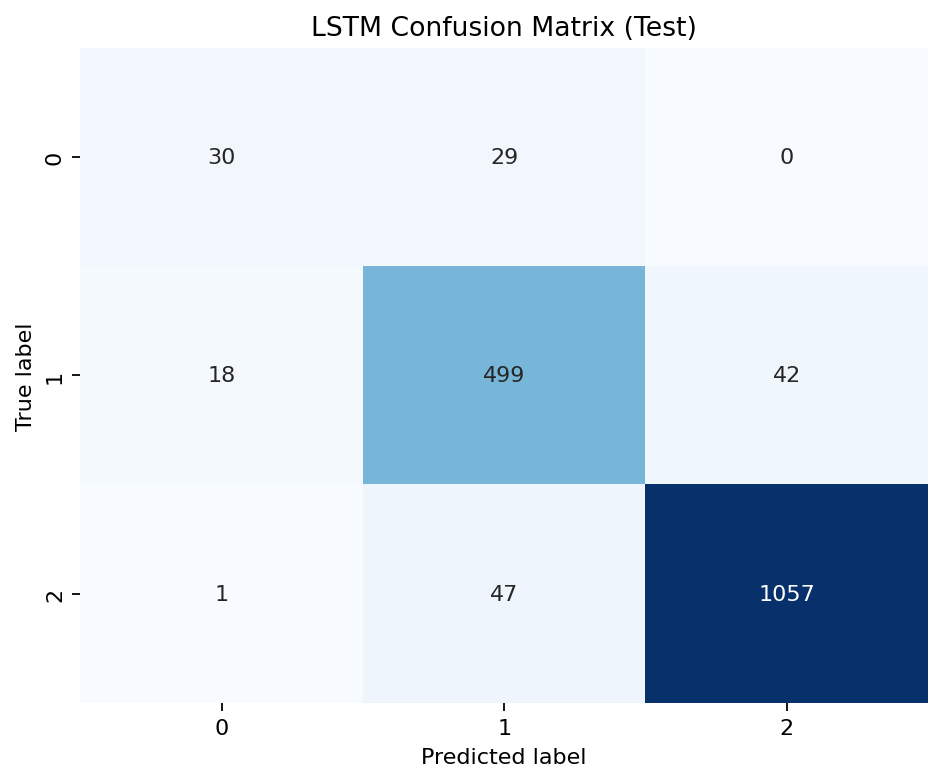

,0,1,2
0,30,29,0
1,18,499,42
2,1,47,1057


Classification report (test set):
              precision    recall  f1-score   support

           0     0.6122    0.5085    0.5556        59
           1     0.8678    0.8927    0.8801       559
           2     0.9618    0.9566    0.9592      1105

    accuracy                         0.9205      1723
   macro avg     0.8140    0.7859    0.7983      1723
weighted avg     0.9193    0.9205    0.9197      1723

Saved: /kaggle/working/credit_rating_artifacts/lstm_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/lstm_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/lstm_test_classification_report.csv


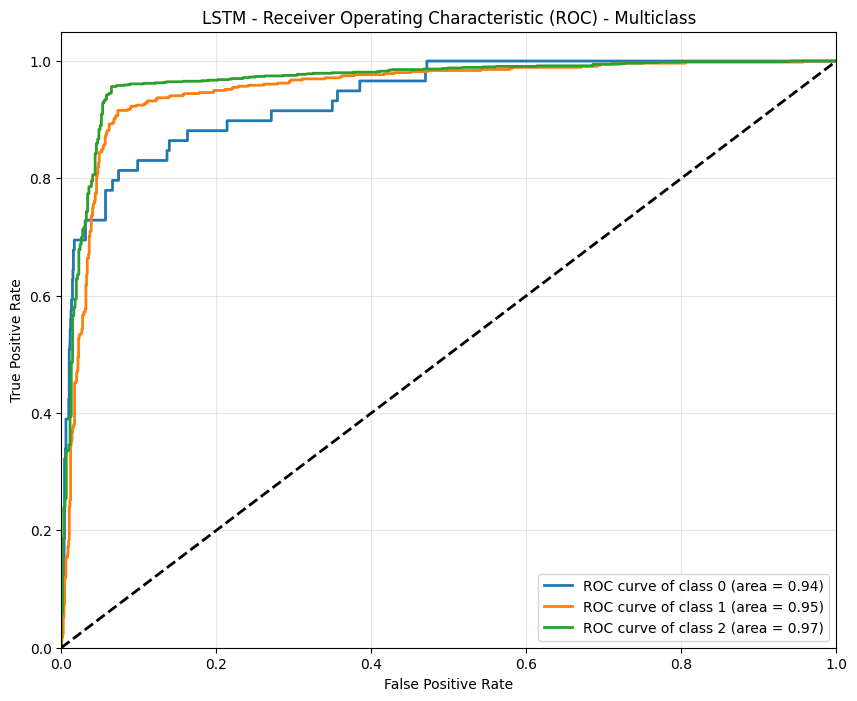

Saved: /kaggle/working/credit_rating_artifacts/lstm_test_roc_curves.png


In [8]:
if 'model' not in globals() or 'test_loader' not in globals():
    raise RuntimeError('Khong tim thay model/test_loader. Hay chay cell huan luyen truoc.')

from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_y_true, all_y_pred, all_logits = [], [], []

with torch.no_grad():
    for batch in test_loader:
        xb, lyb, sb, yb, _ = unpack_lstm_batch(batch)
        xb, lyb, sb = xb.to(device), lyb.to(device), sb.to(device)
        logits = model(xb, lyb, sb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_logits.append(logits.cpu())
        all_y_pred.append(preds)
        all_y_true.append(yb.numpy())

y_true = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
test_logits_all = torch.cat(all_logits)
test_proba = torch.softmax(test_logits_all, dim=1).numpy()

id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_true, y_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LSTM Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'lstm_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set):')
print(classification_report(
    y_true,
    y_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'lstm_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'lstm_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'lstm_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', roc_plot_path)


## xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu model/fusion output cua notebook.
5. **Temporal/fusion context**: baseline neural uu tien financial sequence view; ensemble/DMF giai thich tren probability inputs vi day la input that cua tang ket hop.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


[INFO] xAI for LSTM: rows=1723, feature_source=original_financial_sequence_mean, probability_source=test_proba
[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.
[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.
[INFO] Explained classes: ['0', '1', '2']
[INFO] xAI probability-head fidelity: {'proxy_mse': 0.05128824987402922, 'proxy_argmax_agreement': 0.8479396401625072}


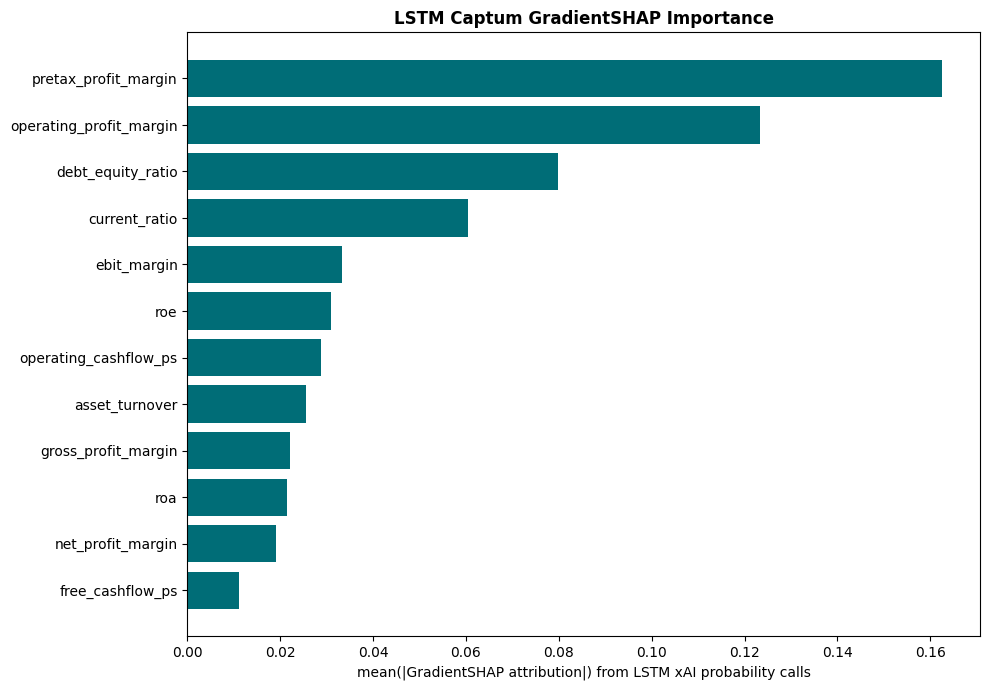

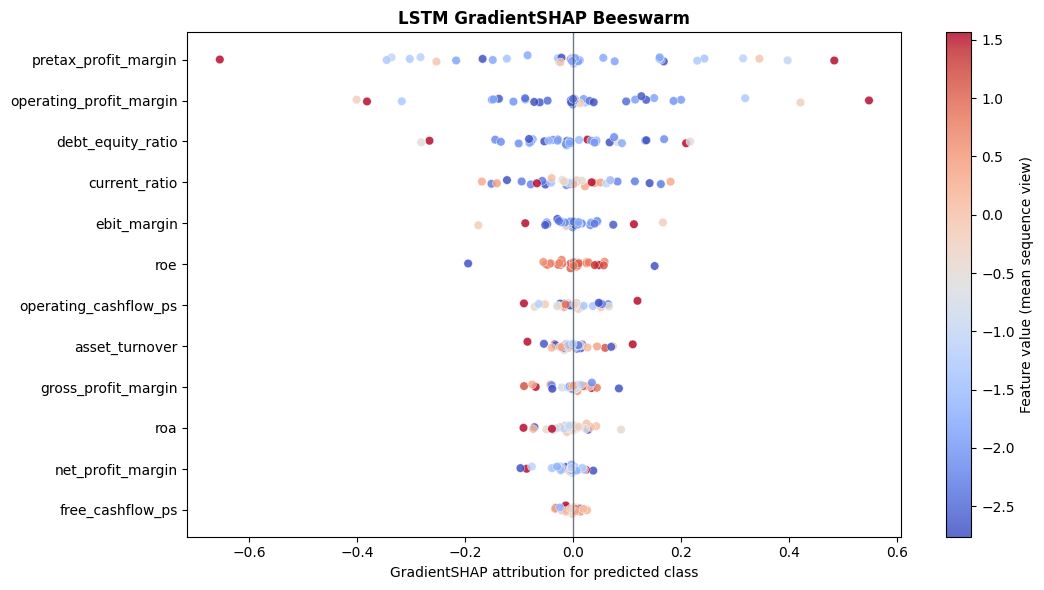


=== Captum GradientSHAP: Why this class? ===

--- Test index 380 | LSTM predicted class=0 | predicted_proba=0.9572 ---
Why this class? class=0 | model_proba=0.9572
  opposes_explained_class    | debt_equity_ratio                             | attribution=-0.03680
  supports_explained_class   | ebit_margin                                   | attribution=+0.02109
  opposes_explained_class    | pretax_profit_margin                          | attribution=-0.02052
  opposes_explained_class    | roe                                           | attribution=-0.01759
  opposes_explained_class    | roa                                           | attribution=-0.01545
Why this class? class=1 | model_proba=0.0374
  supports_explained_class   | pretax_profit_margin                          | attribution=+3.97479
  opposes_explained_class    | operating_profit_margin                       | attribution=-2.12280
  opposes_explained_class    | net_profit_margin                             | attribution

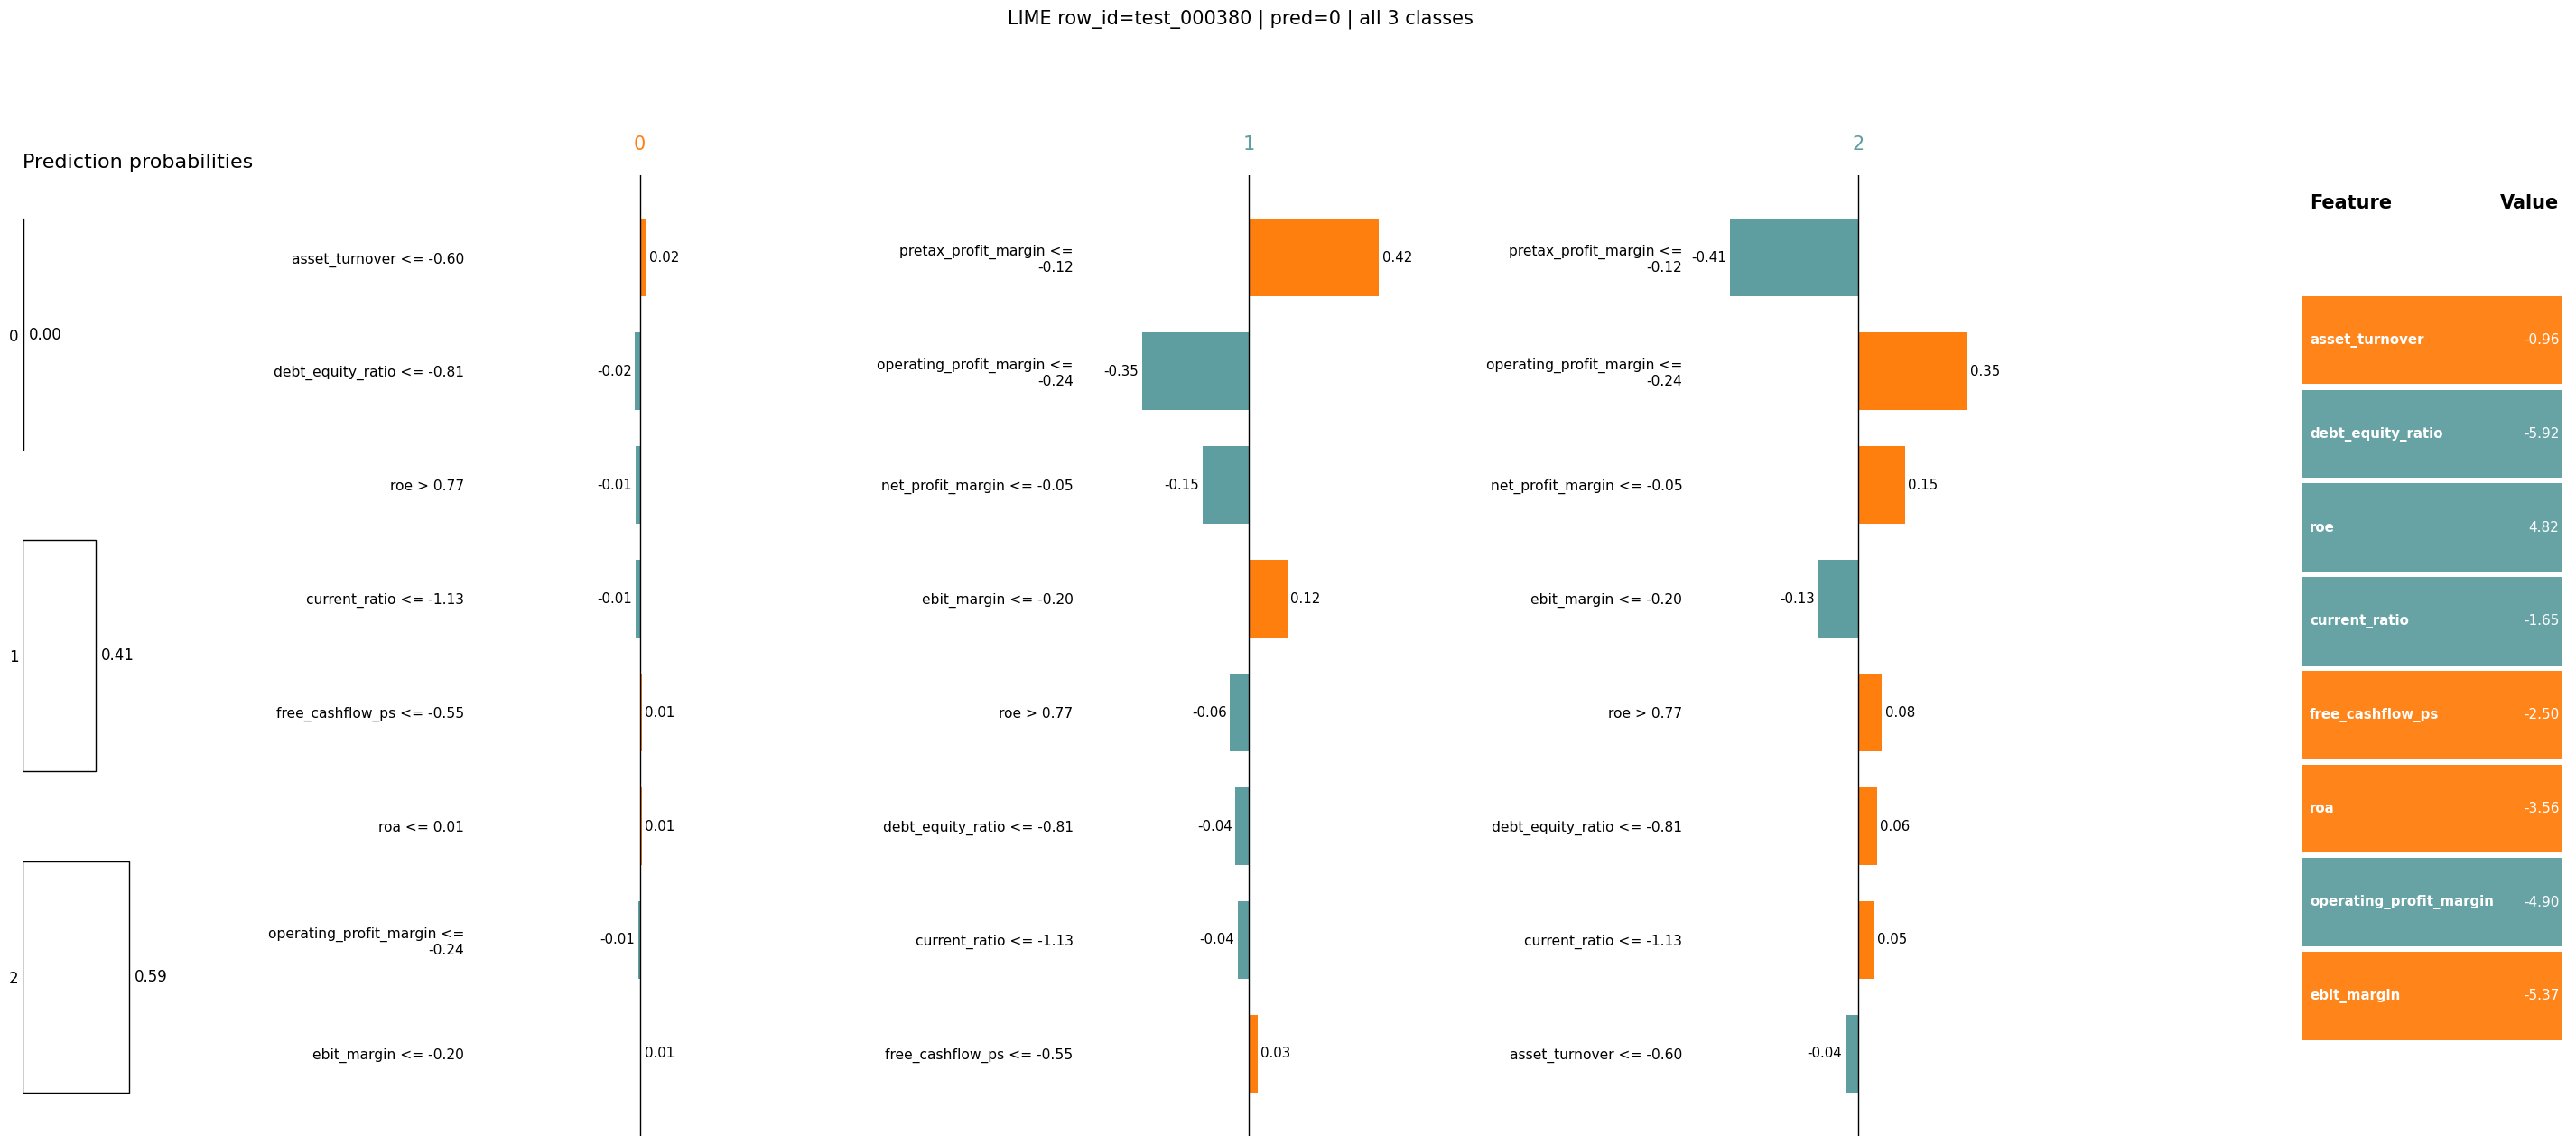

Why this class? class=0 | model_proba=0.9572 | lime_proba=0.0004
  supports_explained_class   | asset_turnover <= -0.60                       | weight=+0.02093
  opposes_explained_class    | debt_equity_ratio <= -0.81                    | weight=-0.01566
  opposes_explained_class    | roe > 0.77                                    | weight=-0.01380
  opposes_explained_class    | current_ratio <= -1.13                        | weight=-0.01351
  supports_explained_class   | free_cashflow_ps <= -0.55                     | weight=+0.00630
Why this class? class=1 | model_proba=0.0374 | lime_proba=0.4074
  supports_explained_class   | pretax_profit_margin <= -0.12                 | weight=+0.42001
  opposes_explained_class    | operating_profit_margin <= -0.24              | weight=-0.34642
  opposes_explained_class    | net_profit_margin <= -0.05                    | weight=-0.15020
  supports_explained_class   | ebit_margin <= -0.20                          | weight=+0.12352
  opposes_expla

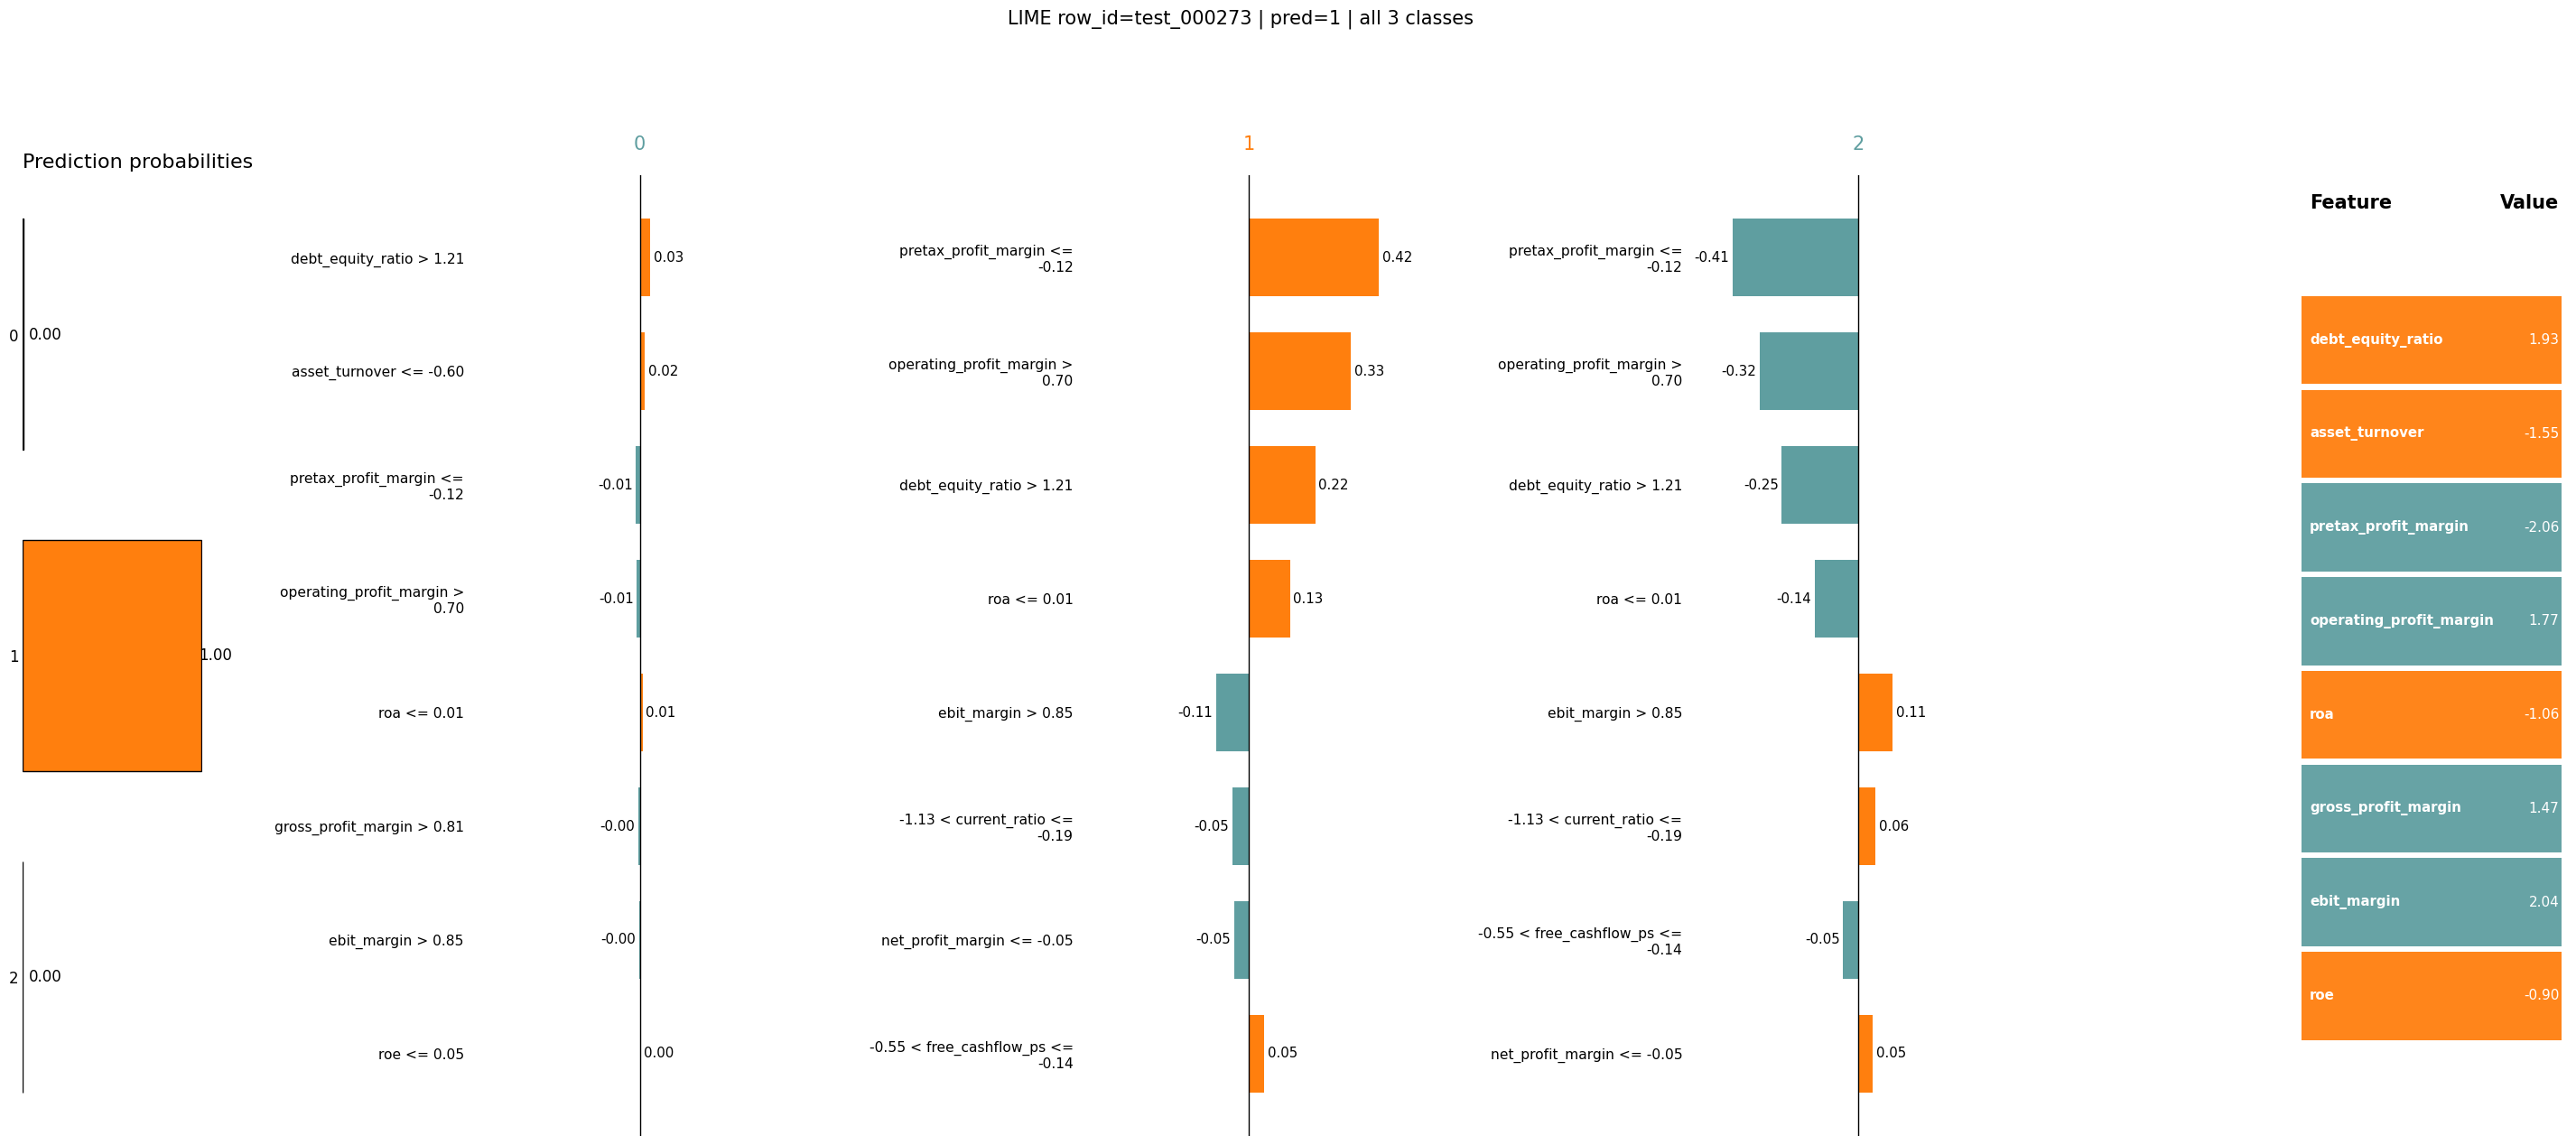

Why this class? class=0 | model_proba=0.0103 | lime_proba=0.0022
  supports_explained_class   | debt_equity_ratio > 1.21                      | weight=+0.03404
  supports_explained_class   | asset_turnover <= -0.60                       | weight=+0.01594
  opposes_explained_class    | pretax_profit_margin <= -0.12                 | weight=-0.01322
  opposes_explained_class    | operating_profit_margin > 0.70                | weight=-0.00946
  supports_explained_class   | roa <= 0.01                                   | weight=+0.00902
Why this class? class=1 | model_proba=0.9864 | lime_proba=0.9978
  supports_explained_class   | pretax_profit_margin <= -0.12                 | weight=+0.42329
  supports_explained_class   | operating_profit_margin > 0.70                | weight=+0.33128
  supports_explained_class   | debt_equity_ratio > 1.21                      | weight=+0.21565
  supports_explained_class   | roa <= 0.01                                   | weight=+0.13310
  opposes_expla

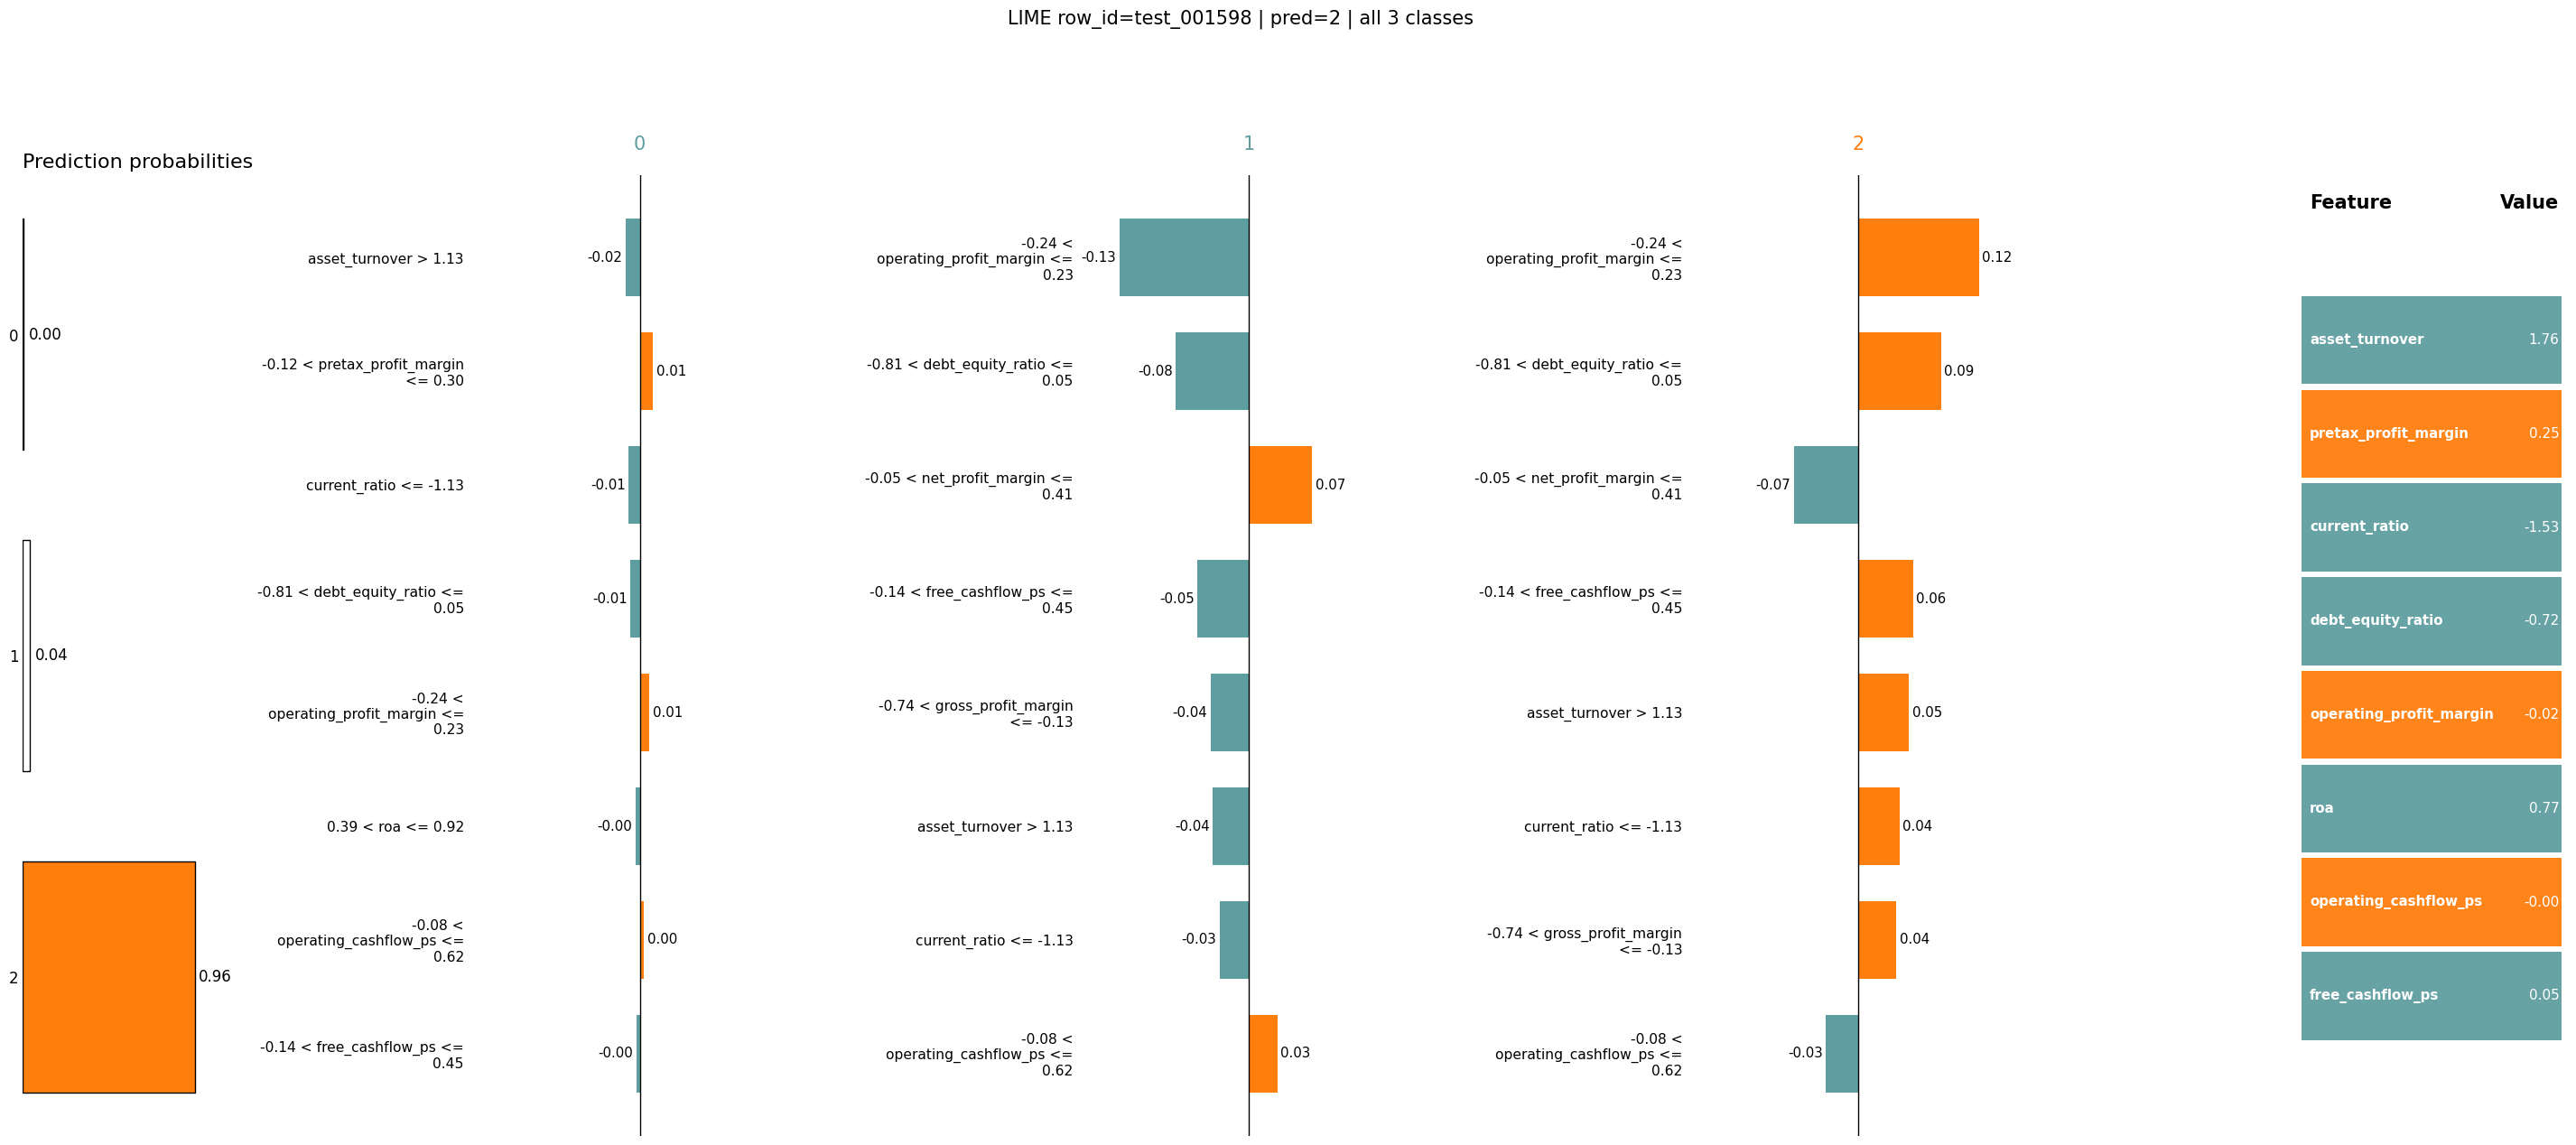

Why this class? class=0 | model_proba=0.0045 | lime_proba=0.0021
  opposes_explained_class    | asset_turnover > 1.13                         | weight=-0.01512
  supports_explained_class   | -0.12 < pretax_profit_margin <= 0.30          | weight=+0.01359
  opposes_explained_class    | current_ratio <= -1.13                        | weight=-0.01170
  opposes_explained_class    | -0.81 < debt_equity_ratio <= 0.05             | weight=-0.00976
  supports_explained_class   | -0.24 < operating_profit_margin <= 0.23       | weight=+0.00961
Why this class? class=1 | model_proba=0.0067 | lime_proba=0.0394
  opposes_explained_class    | -0.24 < operating_profit_margin <= 0.23       | weight=-0.13442
  opposes_explained_class    | -0.81 < debt_equity_ratio <= 0.05             | weight=-0.07568
  supports_explained_class   | -0.05 < net_profit_margin <= 0.41             | weight=+0.06506
  opposes_explained_class    | -0.14 < free_cashflow_ps <= 0.45              | weight=-0.05325
  opposes_expla

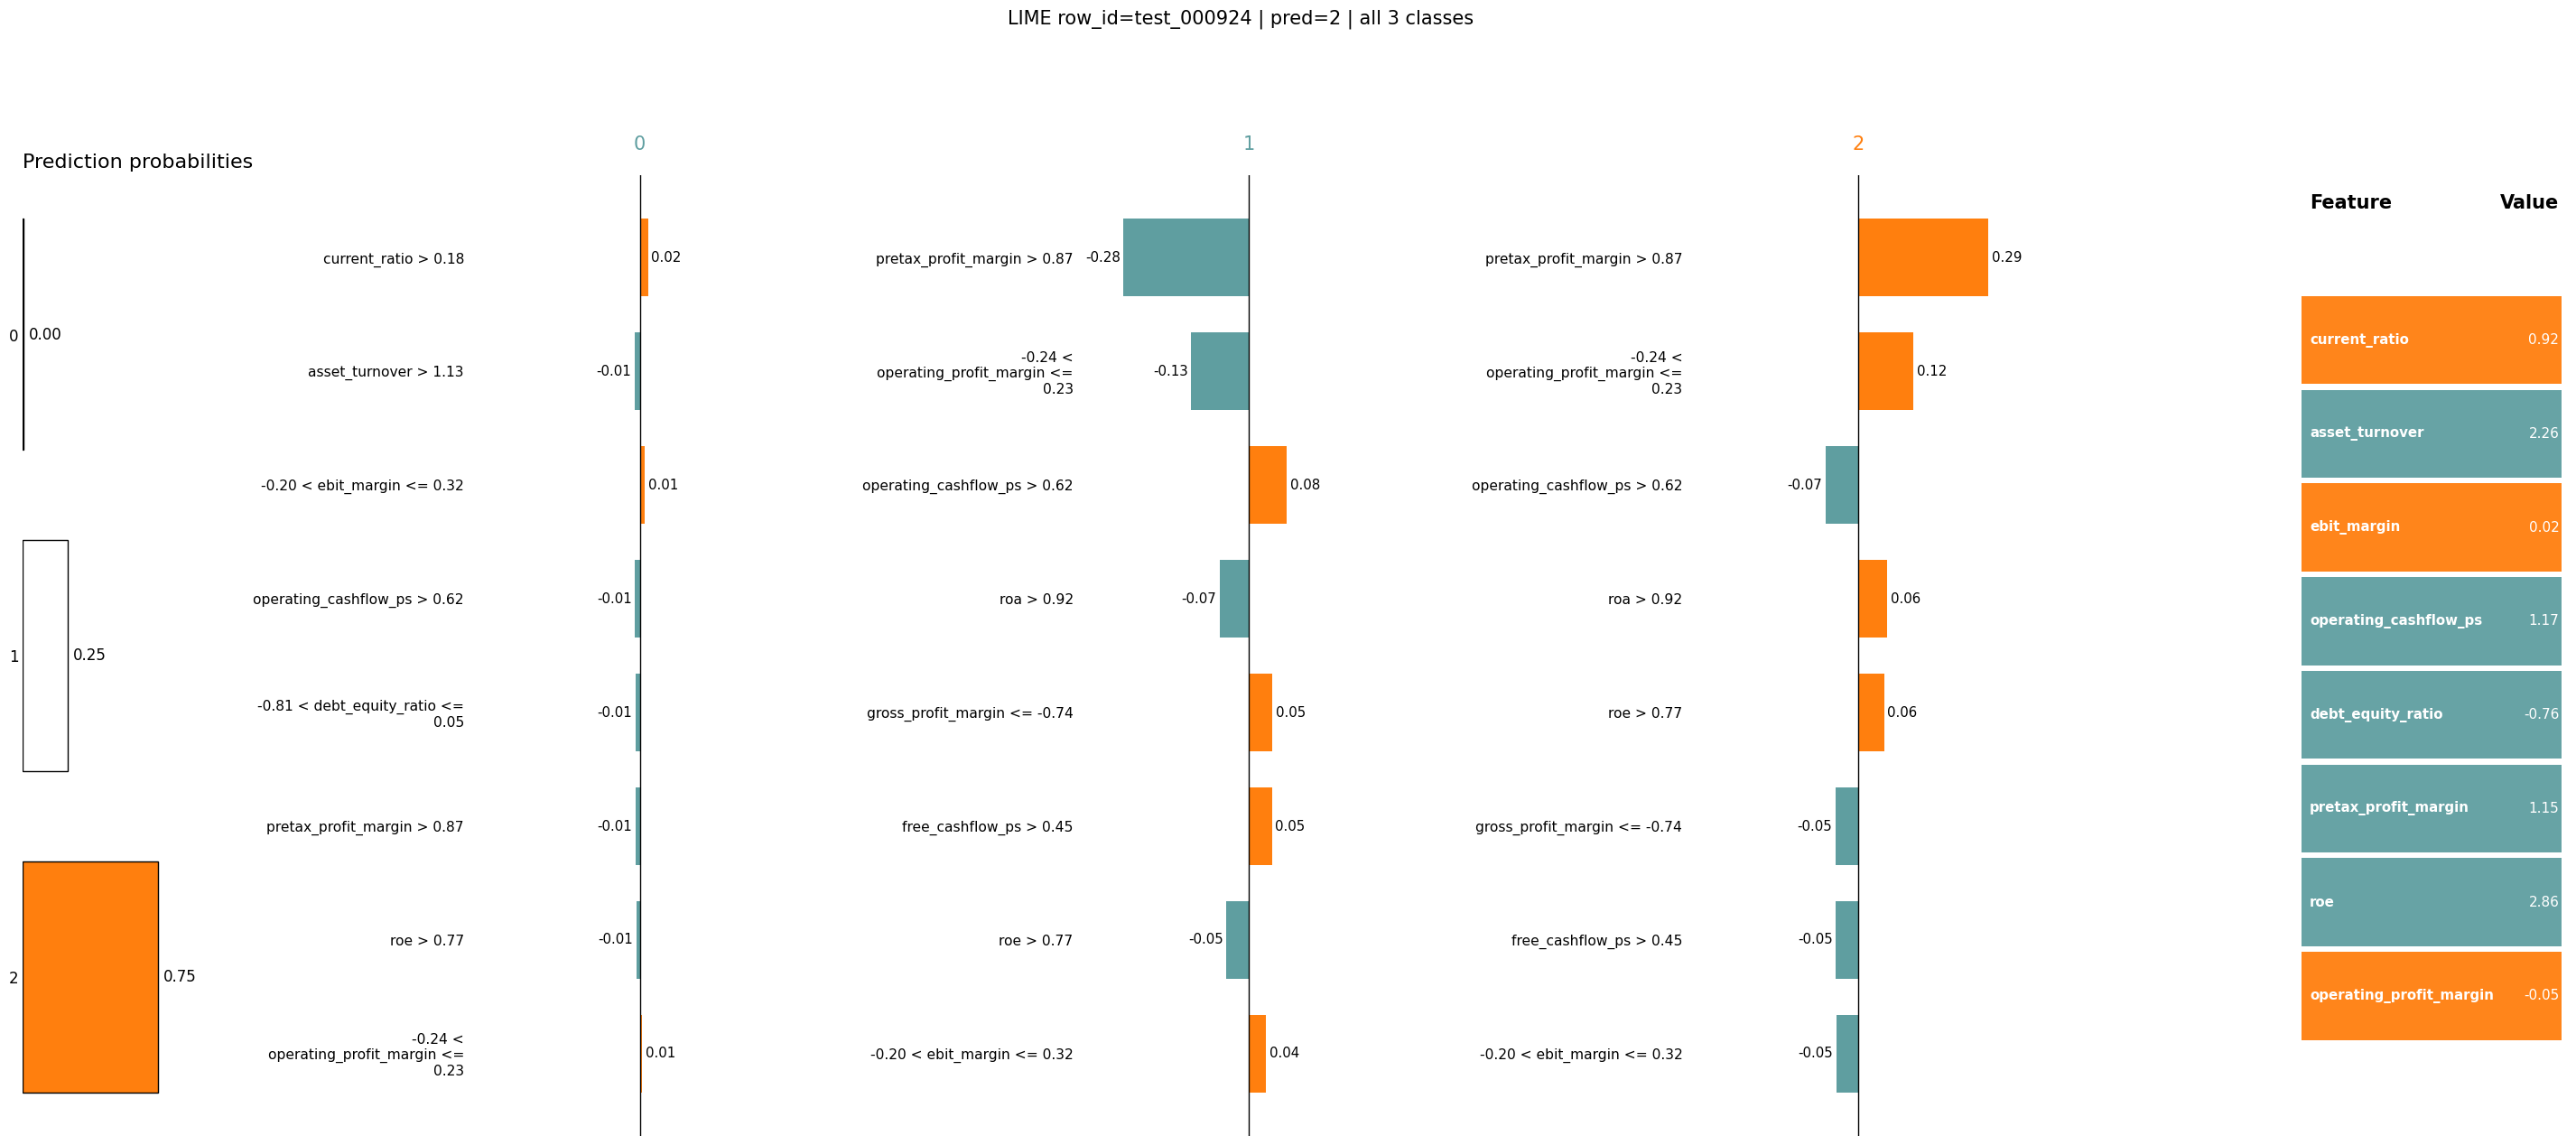

Why this class? class=0 | model_proba=0.0032 | lime_proba=0.0001
  supports_explained_class   | current_ratio > 0.18                          | weight=+0.01807
  opposes_explained_class    | asset_turnover > 1.13                         | weight=-0.01181
  supports_explained_class   | -0.20 < ebit_margin <= 0.32                   | weight=+0.01104
  opposes_explained_class    | operating_cashflow_ps > 0.62                  | weight=-0.01071
  opposes_explained_class    | -0.81 < debt_equity_ratio <= 0.05             | weight=-0.01037
Why this class? class=1 | model_proba=0.0089 | lime_proba=0.2474
  opposes_explained_class    | pretax_profit_margin > 0.87                   | weight=-0.28162
  opposes_explained_class    | -0.24 < operating_profit_margin <= 0.23       | weight=-0.13013
  supports_explained_class   | operating_cashflow_ps > 0.62                  | weight=+0.08498
  opposes_explained_class    | roa > 0.92                                    | weight=-0.06578
  supports_expl

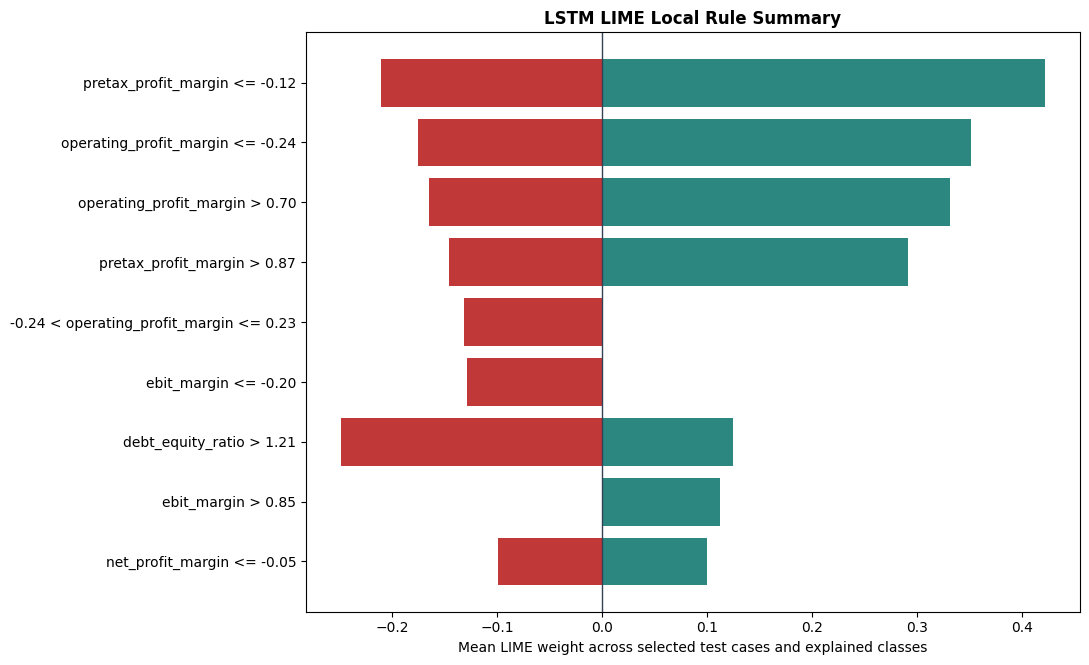

Saved: /kaggle/working/credit_rating_artifacts/lstm_financial_lime_rule_summary.png
Saved per-class local LIME decision explanations to: /kaggle/working/credit_rating_artifacts/lstm_financial_lime_local_decisions.csv


In [9]:
# ============================================================
# xAI Captum GradientSHAP + LIME aligned with Transformer-LSTM presentation
# Main artifacts:
#   {model_key}_financial_shap_importance_by_class.csv
#   {model_key}_financial_shap_global_importance.csv
#   {model_key}_financial_shap_local_decisions.csv
#   {model_key}_financial_lime_local_decisions.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "lstm"
XAI_MODEL_LABEL = "LSTM"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_LOCAL_SAMPLE_COUNT = 4
XAI_LOCAL_TOP_FEATURES = 10
XAI_FINANCIAL_REDUCER = "mean"  # {"mean", "last"}; used when reducing sequence windows.
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id list for local case studies.
XAI_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
XAI_PROXY_MAX_ROWS = 2500
XAI_PROXY_EPOCHS = 220
LIME_NUM_SAMPLES = 600
LIME_USE_DIRECT_MODEL_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8

import math
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError("xAI GradientSHAP requires PyTorch for the differentiable attribution head.") from exc


def _xai_artifact_dir():
    path = globals().get("ARTIFACT_DIR", globals().get("DMF_ARTIFACT_DIR", None))
    if path is None:
        path = Path("/kaggle/working/credit_rating_artifacts") if globals().get("IN_KAGGLE", False) else Path("credit_rating_artifacts")
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_class_names(n_cls):
    if "class_names" in globals() and len(class_names) > 0:
        names = [str(x) for x in class_names]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    if "id_to_name" in globals():
        return [str(id_to_name.get(i, i)) for i in range(n_cls)]
    if "id_to_raw" in globals():
        return [str(id_to_raw.get(i, i)) for i in range(n_cls)]
    if "raw_to_id" in globals():
        inv = {int(v): k for k, v in raw_to_id.items()}
        return [str(inv.get(i, i)) for i in range(n_cls)]
    if "le" in globals() and hasattr(le, "classes_"):
        names = [str(x) for x in le.classes_]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    return [str(i) for i in range(n_cls)]


def _xai_resolve_class_ids(class_ids, n_cls):
    if class_ids is None:
        return list(range(n_cls))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_cls:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_cls - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_prob_columns(frame, prefix=None):
    if prefix is None:
        cols = [c for c in frame.columns if str(c).startswith("prob_")]
    else:
        cols = [c for c in frame.columns if str(c).startswith(f"{prefix}_prob_")]

    def suffix_num(name):
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=suffix_num)


def _xai_get_proba():
    for name in ["dmf_probs", "fp", "test_proba", "test_probs", "weighted_probs", "soft_probs", "y_test_proba"]:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2 and arr.shape[0] > 0:
                return _xai_normalize_proba(arr), name
    if "model" in globals() and "X_test" in globals() and hasattr(model, "predict_proba"):
        X_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        return _xai_normalize_proba(model.predict_proba(X_arr)), "model.predict_proba(X_test)"
    for frame_name in ["test_predictions", "test_results", "test_result_df", "test_results_df", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            cols = _xai_prob_columns(frame)
            if cols:
                return _xai_normalize_proba(frame[cols].to_numpy(dtype=float)), frame_name
    raise RuntimeError("Kh?ng t?m th?y probability matrix cho xAI. H?y ch?y cell inference/evaluation tr??c.")


_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]


def _xai_original_financial_feature_names():
    out = []
    for source_name in ["FINANCIAL_FEATURES", "MODEL_FEATURES", "feature_cols", "financial_cols"]:
        values = globals().get(source_name, [])
        if values is None:
            continue
        try:
            names = [str(v) for v in values]
        except TypeError:
            continue
        for col in _XAI_CANONICAL_FINANCIAL_FEATURES:
            if col in names and col not in out:
                out.append(col)
    return out if out else list(_XAI_CANONICAL_FINANCIAL_FEATURES)


def _xai_financial_indices_from_names(names):
    names = [str(c) for c in names]
    wanted = _xai_original_financial_feature_names()
    cols = [c for c in wanted if c in names]
    idx = [names.index(c) for c in cols]
    return idx, cols


def _xai_frame_financial_values(frame):
    cols = [c for c in _xai_original_financial_feature_names() if c in frame.columns]
    if cols:
        return frame[cols].to_numpy(dtype=np.float64), [str(c) for c in cols]
    return None, []


def _xai_reduce_sequence_to_original_financial(seq, candidate_names):
    seq = np.asarray(seq, dtype=np.float64)
    idx, cols = _xai_financial_indices_from_names(candidate_names)
    if idx:
        return seq[:, :, idx].mean(axis=1), cols
    return seq.mean(axis=1), [str(c) for c in candidate_names]


def _xai_get_feature_view(proba):
    if "test_ds" in globals() and hasattr(test_ds, "samples") and len(test_ds.samples) > 0:
        seq = np.stack([s[0] for s in test_ds.samples], axis=0).astype(np.float64)
        candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(seq.shape[-1])]))
        X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(seq, candidate_names)
        return X_fin, financial_cols, "original_financial_sequence_mean"
    if "test_X_all" in globals():
        arr = np.asarray(test_X_all, dtype=np.float64)
        if arr.ndim == 3:
            candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(arr.shape[-1])]))
            X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(arr, candidate_names)
            return X_fin, financial_cols, "original_financial_sequence_mean"
        if arr.ndim == 2:
            candidate_names = globals().get("flat_feature_names", [f"feature_{i}" for i in range(arr.shape[1])])
            idx, financial_cols = _xai_financial_indices_from_names(candidate_names)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_flat_features"
            if "MODEL_FEATURES" in globals() and arr.shape[1] == len(MODEL_FEATURES):
                idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
                if idx:
                    return arr[:, idx], financial_cols, "original_financial_tabular_features"
            return arr, [str(c) for c in candidate_names], "flattened_sequence"
    if "X_test" in globals():
        if isinstance(X_test, pd.DataFrame):
            X_fin, financial_cols = _xai_frame_financial_values(X_test)
            if financial_cols:
                return X_fin, financial_cols, "original_financial_tabular_features"
            arr = X_test.values
        else:
            arr = np.asarray(X_test)
        arr = np.asarray(arr, dtype=np.float64)
        if "MODEL_FEATURES" in globals() and arr.ndim == 2 and arr.shape[1] == len(MODEL_FEATURES):
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_tabular_features"
        if "MODEL_FEATURES" in globals() and "INPUT_SIZE" in globals() and arr.ndim == 2 and arr.shape[1] >= int(INPUT_SIZE) * len(MODEL_FEATURES):
            n_base = len(MODEL_FEATURES)
            window = arr[:, :int(INPUT_SIZE) * n_base].reshape(arr.shape[0], int(INPUT_SIZE), n_base)
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return window[:, :, idx].mean(axis=1), financial_cols, "original_financial_tabular_window_mean"
        cols = list(X_test.columns) if isinstance(X_test, pd.DataFrame) else [f"feature_{i}" for i in range(arr.shape[1])]
        idx, financial_cols = _xai_financial_indices_from_names(cols)
        if idx:
            return arr[:, idx], financial_cols, "original_financial_tabular_features"
        return arr, [str(c) for c in cols], "tabular_features"
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        X_fin, financial_cols = _xai_frame_financial_values(frame)
        if financial_cols:
            return X_fin, financial_cols, "df_test_mask_original_financial_features"
    for frame_name in ["test_df", "df_test", "test_rows", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            X_fin, financial_cols = _xai_frame_financial_values(frame)
            if financial_cols:
                return X_fin, financial_cols, f"{frame_name}_original_financial_features"
            prob_cols = []
            for prefix in ["tlstm", "gat", "lstm", "tcn", "patchtst", "xgboost", "lightgbm", "dmf"]:
                prob_cols.extend(_xai_prob_columns(frame, prefix=prefix))
            if prob_cols:
                return frame[prob_cols].to_numpy(dtype=np.float64), [str(c) for c in prob_cols], f"{frame_name}_probability_inputs"
    if "test_probas" in globals() and isinstance(test_probas, list) and len(test_probas) > 0:
        mats = [np.asarray(p, dtype=np.float64) for p in test_probas]
        if all(m.ndim == 2 for m in mats):
            names = globals().get("MODEL_NAMES", [f"model_{i}" for i in range(len(mats))])
            feature_cols = []
            for model_name, mat in zip(names, mats):
                for class_idx in range(mat.shape[1]):
                    feature_cols.append(f"{model_name}_prob_{class_idx}")
            return np.concatenate(mats, axis=1), feature_cols, "ensemble_probability_inputs"
    return np.asarray(proba, dtype=np.float64), [f"predicted_prob_{i}" for i in range(proba.shape[1])], "model_probability_vector"


def _xai_metadata(n_rows):
    meta_cols = ["row_id", "ticker", "company_name", "rating_date", "sector", "true_label", "true_label_name"]
    for frame_name in ["test_df", "df_test", "test_rows", "out", "test_predictions", "test_results_df"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame) and len(globals()[frame_name]) >= n_rows:
            frame = globals()[frame_name].reset_index(drop=True)
            cols = [c for c in meta_cols if c in frame.columns]
            if cols:
                return frame.loc[:n_rows - 1, cols].copy()
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        cols = [c for c in meta_cols if c in frame.columns]
        if cols and len(frame) >= n_rows:
            return frame.loc[:n_rows - 1, cols].copy()
    meta = pd.DataFrame({"test_index": np.arange(n_rows, dtype=int)})
    if "y_test" in globals() and len(y_test) >= n_rows:
        meta["true_label"] = np.asarray(y_test[:n_rows], dtype=int)
    elif "y_true" in globals() and len(y_true) >= n_rows:
        meta["true_label"] = np.asarray(y_true[:n_rows], dtype=int)
    return meta


def _xai_select_indices(meta, proba):
    n_rows = len(meta)
    if XAI_ROW_IDS is not None and "row_id" in meta.columns:
        wanted = {str(x) for x in XAI_ROW_IDS}
        idx = [int(i) for i, row_id in enumerate(meta["row_id"].astype(str)) if row_id in wanted]
        if idx:
            return idx[:XAI_LOCAL_SAMPLE_COUNT]
    confidence = proba.max(axis=1)
    ranked = np.argsort(-confidence)
    selected = []
    preds = proba.argmax(axis=1)
    for class_id in np.unique(preds[ranked]):
        class_ranked = [int(i) for i in ranked if preds[i] == class_id]
        if class_ranked:
            selected.append(class_ranked[0])
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    for i in ranked:
        i = int(i)
        if i not in selected:
            selected.append(i)
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    return selected


class _XAIProbabilityHead(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        hidden = int(min(96, max(16, 2 * n_features)))
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x.float()), dim=1)


def _xai_train_probability_head(X_view, proba):
    rng = np.random.default_rng(XAI_RANDOM_STATE)
    X_view = np.asarray(X_view, dtype=np.float64)
    proba = _xai_normalize_proba(proba)
    center = np.nanmedian(X_view, axis=0)
    scale = np.nanstd(X_view, axis=0)
    scale = np.where(scale < 1e-8, 1.0, scale)
    X_std = np.nan_to_num((X_view - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
    n_rows = len(X_std)
    fit_idx = np.arange(n_rows)
    if n_rows > XAI_PROXY_MAX_ROWS:
        fit_idx = rng.choice(n_rows, size=XAI_PROXY_MAX_ROWS, replace=False)
    device_xai = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    head = _XAIProbabilityHead(X_std.shape[1], proba.shape[1]).to(device_xai)
    x_train = torch.tensor(X_std[fit_idx], dtype=torch.float32, device=device_xai)
    y_train = torch.tensor(proba[fit_idx], dtype=torch.float32, device=device_xai)
    opt = torch.optim.AdamW(head.parameters(), lr=0.01, weight_decay=1e-4)
    head.train()
    for _ in range(int(XAI_PROXY_EPOCHS)):
        opt.zero_grad(set_to_none=True)
        pred = head(x_train)
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        opt.step()
    head.eval()
    with torch.no_grad():
        pred_all = head(torch.tensor(X_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    fidelity = {
        "proxy_mse": float(np.mean((pred_all - proba) ** 2)),
        "proxy_argmax_agreement": float(np.mean(pred_all.argmax(axis=1) == proba.argmax(axis=1))),
    }
    return head, X_std.astype(np.float32), center, scale, device_xai, fidelity


def _xai_predict_from_head(head, center, scale, device_xai, x_batch):
    x_batch = np.asarray(x_batch, dtype=np.float64)
    if x_batch.ndim == 1:
        x_batch = x_batch.reshape(1, -1)
    x_std = np.nan_to_num((x_batch - center) / scale, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    with torch.no_grad():
        pred = head(torch.tensor(x_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    return _xai_normalize_proba(pred)


def _xai_gradientshap_attributions(head, X_std, sample_indices, background_indices, class_ids, device_xai):
    x_samples = torch.tensor(X_std[sample_indices], dtype=torch.float32, device=device_xai)
    baselines = torch.tensor(X_std[background_indices], dtype=torch.float32, device=device_xai)
    method = "captum_gradientshap_probability_head"
    attributions = {}
    try:
        from captum.attr import GradientShap
        gs = GradientShap(head)
        for class_id in class_ids:
            attr = gs.attribute(
                x_samples,
                baselines=baselines,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            attributions[int(class_id)] = attr.detach().cpu().numpy()
    except Exception as exc:
        method = f"expected_gradients_fallback: {type(exc).__name__}"
        rng = np.random.default_rng(XAI_RANDOM_STATE)
        for class_id in class_ids:
            rows = []
            for x_np in X_std[sample_indices]:
                accum = []
                for _ in range(int(GRADIENT_SHAP_N_SAMPLES)):
                    b_np = X_std[int(rng.choice(background_indices))]
                    alpha = float(rng.uniform(0.0, 1.0))
                    noise = rng.normal(0.0, float(GRADIENT_SHAP_STDEV), size=x_np.shape).astype(np.float32)
                    interp_np = b_np + alpha * (x_np - b_np) + noise
                    interp = torch.tensor(interp_np.reshape(1, -1), dtype=torch.float32, device=device_xai, requires_grad=True)
                    score = head(interp)[:, int(class_id)].sum()
                    grad = torch.autograd.grad(score, interp)[0].detach().cpu().numpy()[0]
                    accum.append((x_np - b_np) * grad)
                rows.append(np.mean(accum, axis=0))
            attributions[int(class_id)] = np.asarray(rows, dtype=np.float32)
    return attributions, method


def _xai_lime_fallback(x_row, predict_fn, class_id, feature_names, num_features):
    rng = np.random.default_rng(XAI_RANDOM_STATE + int(class_id))
    x_row = np.asarray(x_row, dtype=np.float64)
    perturb = rng.normal(loc=x_row, scale=np.maximum(np.nanstd(x_row), 1e-3), size=(int(LIME_NUM_SAMPLES), len(x_row)))
    perturb[0] = x_row
    probs = _xai_normalize_proba(predict_fn(perturb))[:, int(class_id)]
    distances = np.linalg.norm(perturb - x_row.reshape(1, -1), axis=1)
    kernel_width = math.sqrt(len(x_row)) * 0.75
    weights = np.exp(-(distances ** 2) / max(kernel_width ** 2, 1e-9))
    X_aug = np.column_stack([np.ones(len(perturb)), perturb - x_row.reshape(1, -1)])
    W = np.sqrt(weights).reshape(-1, 1)
    coef = np.linalg.lstsq(X_aug * W, probs * W.ravel(), rcond=None)[0][1:]
    order = np.argsort(-np.abs(coef))[:num_features]
    return [(str(feature_names[j]), float(coef[j])) for j in order]



def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text

def _xai_save_lime_multiclass_instance_plot(row_meta, exp, model_proba, lime_proba, x_row, html_path, lime_available):
    from matplotlib.patches import Rectangle

    row_id = str(row_meta.get("row_id", row_meta.get("test_index", "unknown")))
    safe_row_id = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in row_id)
    class_ids = list(explain_class_ids)
    if lime_available and exp is not None:
        class_items = {
            int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
            for class_id in class_ids
        }
    else:
        class_items = {
            int(class_id): _xai_lime_fallback(x_row, _xai_probability_fn, int(class_id), feature_cols, min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES)))
            for class_id in class_ids
        }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names_xai))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names_xai))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names_xai], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names_xai[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_cols)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_cols:
                feat_value = float(x_row[feature_cols.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    title = f"LIME row_id={row_id} | pred={class_names_xai[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{safe_row_id}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


proba, proba_source = _xai_get_proba()
X_view, feature_cols, feature_source = _xai_get_feature_view(proba)
X_view = np.asarray(X_view, dtype=np.float64)
n_rows = min(len(X_view), len(proba))
X_view = X_view[:n_rows]
proba = proba[:n_rows]
class_names_xai = _xai_class_names(proba.shape[1])
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS, proba.shape[1])
meta = _xai_metadata(n_rows).reset_index(drop=True)
selected_indices = _xai_select_indices(meta, proba)
background_size = min(int(XAI_BACKGROUND_SIZE), n_rows)
rng = np.random.default_rng(XAI_RANDOM_STATE)
background_indices = rng.choice(n_rows, size=background_size, replace=False) if n_rows > background_size else np.arange(n_rows)
grad_sample_size = min(int(SHAP_MAX_SAMPLES), n_rows)
grad_sample_indices = rng.choice(n_rows, size=grad_sample_size, replace=False) if n_rows > grad_sample_size else np.arange(n_rows)

print(f"[INFO] xAI for {XAI_MODEL_LABEL}: rows={n_rows}, feature_source={feature_source}, probability_source={proba_source}")
print("[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.")
print("[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.")
print("[INFO] Explained classes:", [class_names_xai[i] for i in explain_class_ids])

xai_head, X_std, xai_center, xai_scale, xai_device, proxy_fidelity = _xai_train_probability_head(X_view, proba)
print("[INFO] xAI probability-head fidelity:", proxy_fidelity)


def _xai_probability_fn(x_batch):
    return _xai_predict_from_head(xai_head, xai_center, xai_scale, xai_device, x_batch)

if SHAP_FINANCIAL_ENABLED:
    attrs_by_class, gradientshap_method = _xai_gradientshap_attributions(
        xai_head, X_std, grad_sample_indices, background_indices, explain_class_ids, xai_device
    )
    global_rows = []
    for class_id, attrs in attrs_by_class.items():
        mean_abs = np.mean(np.abs(attrs), axis=0)
        signed = np.mean(attrs, axis=0)
        for rank, j in enumerate(np.argsort(-mean_abs), start=1):
            global_rows.append({
                "rank": int(rank), "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                "class_id": int(class_id), "class_name": class_names_xai[class_id],
                "feature": str(feature_cols[j]), "mean_abs_gradientshap": float(mean_abs[j]),
                "mean_signed_gradientshap": float(signed[j]), "feature_source": feature_source,
                "probability_source": proba_source, "gradientshap_method": gradientshap_method,
                "xai_method": "captum_gradient_shap" if "captum" in gradientshap_method else "expected_gradients_fallback",
                "xai_probability_source": proba_source,
                "proxy_mse": proxy_fidelity["proxy_mse"], "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
            })
    gradient_global_df = pd.DataFrame(global_rows)
    shap_importance_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    gradient_global_df.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global = (
        gradient_global_df.groupby("feature", as_index=False)
        .agg(mean_abs_shap_value=("mean_abs_gradientshap", "mean"), mean_signed_shap_value=("mean_signed_gradientshap", "mean"))
        .sort_values("mean_abs_shap_value", ascending=False)
        .reset_index(drop=True)
    )
    shap_global["rank"] = np.arange(1, len(shap_global) + 1)
    shap_global["model_key"] = XAI_MODEL_KEY
    shap_global["model_label"] = XAI_MODEL_LABEL
    shap_global["feature_source"] = feature_source
    shap_global["probability_source"] = proba_source
    shap_global["xai_probability_source"] = proba_source
    shap_global_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    top_global = shap_global.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"][::-1], top_global["mean_abs_shap_value"][::-1], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel(f"mean(|GradientSHAP attribution|) from {XAI_MODEL_LABEL} xAI probability calls")
    plt.tight_layout()
    shap_bar_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(XAI_BEESWARM_TOP_FEATURES, len(shap_global)))["feature"].tolist()
    beeswarm_idx = [feature_cols.index(f) for f in beeswarm_features if f in feature_cols]
    if beeswarm_idx:
        beeswarm_rows = []
        for class_id, attrs in attrs_by_class.items():
            for local_pos, row_idx in enumerate(grad_sample_indices):
                for feat_idx in beeswarm_idx:
                    beeswarm_rows.append({
                        "class_name": class_names_xai[class_id],
                        "feature": feature_cols[feat_idx],
                        "feature_value": float(X_view[row_idx, feat_idx]),
                        "shap_value": float(attrs[local_pos, feat_idx]),
                    })
        beeswarm_df = pd.DataFrame(beeswarm_rows)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        y_positions = {feature: pos for pos, feature in enumerate(reversed(beeswarm_features))}
        for feature in beeswarm_features:
            subset = beeswarm_df[beeswarm_df["feature"] == feature]
            if subset.empty:
                continue
            jitter = np.random.default_rng(XAI_RANDOM_STATE).normal(0, 0.05, size=len(subset))
            plt.scatter(subset["shap_value"], y_positions[feature] + jitter, c=subset["feature_value"], cmap="coolwarm", s=38, alpha=0.82, edgecolors="white", linewidths=0.35)
        plt.yticks(list(y_positions.values()), list(y_positions.keys()))
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        plt.xlabel("GradientSHAP attribution for predicted class")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        beeswarm_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(_xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

    local_rows = []
    print()
    print("=== Captum GradientSHAP: Why this class? ===")
    selected_attr_lookup = {}
    selected_attrs, selected_method = _xai_gradientshap_attributions(
        xai_head, X_std, selected_indices, background_indices, explain_class_ids, xai_device
    )
    for pos, idx in enumerate(selected_indices):
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[int(idx)].to_dict() if len(meta) > int(idx) else {"test_index": int(idx)}
        print()
        print(f"--- Test index {int(idx)} | {XAI_MODEL_LABEL} predicted class={pred_name} | predicted_proba={proba[idx, pred_id]:.4f} ---")
        for class_id in explain_class_ids:
            attr = selected_attrs[int(class_id)][pos]
            order = np.argsort(-np.abs(attr))[:min(XAI_LOCAL_TOP_FEATURES, len(feature_cols))]
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f}")
            for rank, j in enumerate(order, start=1):
                weight = float(attr[j])
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {feature_cols[j]:<45} | attribution={weight:+.5f}")
                local_rows.append({
                    **row_meta, "test_index": int(idx), "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "feature": str(feature_cols[j]), "feature_value": float(X_view[idx, j]),
                    "gradientshap_attribution": weight, "direction": direction,
                    "feature_source": feature_source, "probability_source": proba_source,
                    "xai_probability_source": proba_source,
                    "xai_method": "captum_gradient_shap" if "captum" in selected_method else "expected_gradients_fallback",
                    "gradientshap_method": selected_method,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                })
    gradient_local_df = pd.DataFrame(local_rows)
    shap_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    gradient_local_df.to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print("Saved:", shap_importance_path)
    print("Saved:", shap_global_path)
    print("Saved:", shap_bar_path)
    if "beeswarm_path" in locals():
        print("Saved:", beeswarm_path)
    print("Saved:", shap_local_path)
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    try:
        import lime
        import lime.lime_tabular
        lime_available = True
    except Exception:
        lime_available = False

    if lime_available:
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_view[background_indices],
            feature_names=[str(c) for c in feature_cols],
            class_names=class_names_xai,
            mode="classification",
            discretize_continuous=True,
            random_state=int(XAI_RANDOM_STATE),
        )
        print("[INFO] LIME package available; using LimeTabularExplainer.")
    else:
        explainer = None
        print("[WARN] Package 'lime' is not available; using weighted local-linear LIME fallback.")

    lime_rows = []
    print()
    print("=== Direct LIME using notebook probability outputs ===")
    for idx in selected_indices:
        idx = int(idx)
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[idx].to_dict() if len(meta) > idx else {"test_index": idx}
        lime_proba = _xai_probability_fn(X_view[idx].reshape(1, -1))[0]
        print()
        print(f"--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={pred_name} | model_proba={proba[idx, pred_id]:.4f} | lime_proba={lime_proba[pred_id]:.4f} ---")
        html_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_test_idx_{idx}.html"
        exp = None
        if lime_available:
            exp = explainer.explain_instance(
                data_row=X_view[idx],
                predict_fn=_xai_probability_fn,
                num_features=min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)),
                labels=explain_class_ids,
                num_samples=int(LIME_NUM_SAMPLES),
            )
            try:
                exp.save_to_file(str(html_path))
            except Exception as exc:
                print(f"[WARN] Could not save LIME HTML for idx={idx}: {exc}")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row_meta=row_meta, exp=exp, model_proba=proba[idx], lime_proba=lime_proba,
            x_row=X_view[idx], html_path=html_path, lime_available=lime_available,
        )
        for class_id in explain_class_ids:
            if lime_available and exp is not None:
                items = [(str(rule), float(weight)) for rule, weight in exp.as_list(label=int(class_id))]
                lime_source = "LimeTabularExplainer"
            else:
                items = _xai_lime_fallback(X_view[idx], _xai_probability_fn, int(class_id), feature_cols, min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)))
                lime_source = "weighted_local_linear_fallback"
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f} | lime_proba={lime_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(items, start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    **row_meta, "test_index": idx, "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_rule": str(rule), "lime_weight_for_explained_class": float(weight),
                    "direction": direction, "feature_source": feature_source,
                    "probability_source": proba_source, "lime_probability_source": lime_source,
                    "xai_probability_source": proba_source,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                    "html_path": str(html_path) if lime_available else "",
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", lime_plot_path)
    print("Saved per-class local LIME decision explanations to:", lime_local_path)
else:
    print("LIME disabled. Set LIME_FINANCIAL_ENABLED=True to run.")


## Visualization: Training Curves

Biểu đồ train/validation theo chuẩn bài báo khoa học cho 5 metric: Loss, Accuracy, Macro F1, AUC, QWK.

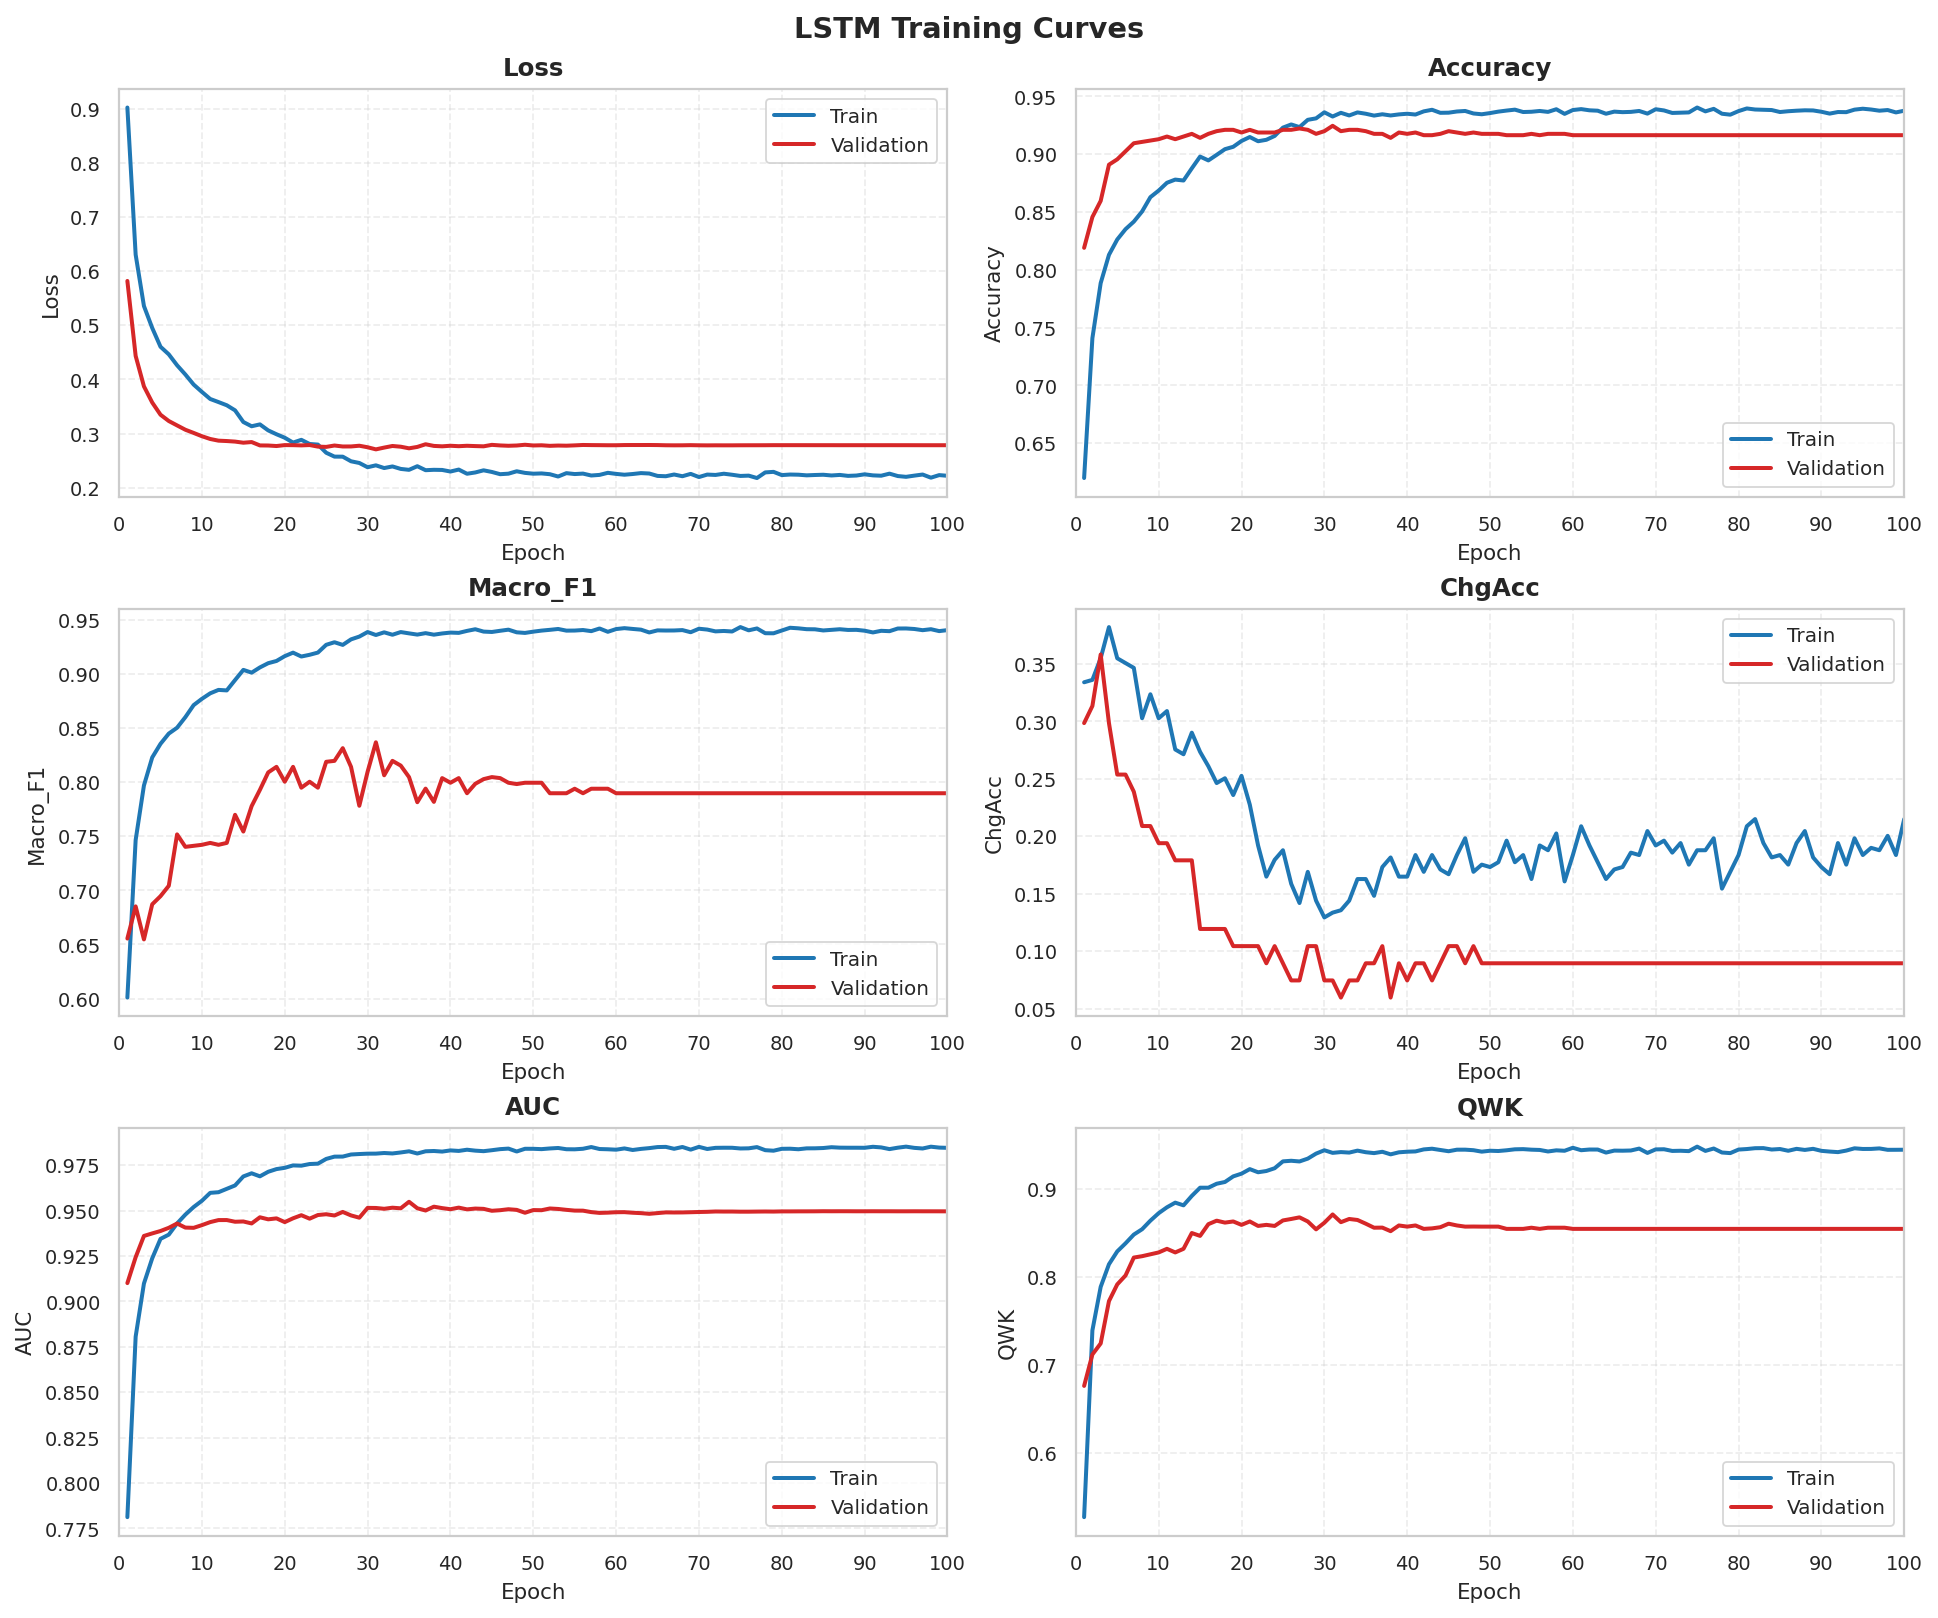

Saved: /kaggle/working/credit_rating_artifacts/lstm_training_curves.png


In [10]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

from matplotlib.ticker import MultipleLocator

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'ChgAcc', 'AUC', 'QWK']
required_cols = [f'train_{m}' for m in metrics] + [f'val_{m}' for m in metrics]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()
max_epoch = int(history_df['epoch'].max())

for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label='Validation', linewidth=1.8, color='#d62728')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, max_epoch)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle('LSTM Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'lstm_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)



## Export OOF Probabilities

Lưu xác suất dự đoán (val + test) để dùng trong Fuzzy Choquet Ensemble (KB7/KB8/KB9).


In [11]:
# [AUTO] EXPORT OOF PROBABILITIES + DMF CSV CONTRACT
# Luu xac suat val/test cho Ensemble va file CSV co row_id de dung trong DMF/DCS.
# Chay cell nay SAU KHI notebook da huan luyen xong.

import numpy as np
import torch

_MODEL_KEY = 'lstm'


def _as_list(values):
    if values is None:
        return None
    if isinstance(values, torch.Tensor):
        return values.detach().cpu().numpy().tolist()
    if isinstance(values, (list, tuple)):
        return list(values)
    return list(values)


# Buoc 1: Forward pass de khoi phuc y/proba/metadata neu thieu.
def _extract_and_predict(model_obj, loader_obj, device_obj):
    model_obj.eval()
    all_y, all_prob = [], []
    all_row_ids, all_tickers, all_dates = [], [], []
    with torch.no_grad():
        for batch in loader_obj:
            if len(batch) == 7:
                xb, lyb, sb, yb, row_ids, tickers, rating_dates = batch
            elif len(batch) == 4:
                xb, lyb, sb, yb = batch
                batch_size = len(yb)
                row_ids = [f'unknown_{len(all_y):06d}_{i:04d}' for i in range(batch_size)]
                tickers = [''] * batch_size
                rating_dates = [''] * batch_size
            elif len(batch) == 2:
                xb, yb = batch
                lyb, sb = None, None
                batch_size = len(yb)
                row_ids = [f'unknown_{len(all_y):06d}_{i:04d}' for i in range(batch_size)]
                tickers = [''] * batch_size
                rating_dates = [''] * batch_size
            else:
                xb = batch[0]
                yb = batch[-1]
                lyb = batch[1] if len(batch) > 2 else None
                sb = batch[2] if len(batch) > 3 else None
                batch_size = len(yb)
                row_ids = [f'unknown_{len(all_y):06d}_{i:04d}' for i in range(batch_size)]
                tickers = [''] * batch_size
                rating_dates = [''] * batch_size
            xb = xb.to(device_obj)
            if lyb is not None:
                lyb = lyb.to(device_obj)
            if sb is not None:
                sb = sb.to(device_obj)
            if lyb is not None and sb is not None:
                logits = model_obj(xb, lyb, sb)
            else:
                logits = model_obj(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            all_prob.append(prob)
            all_y.append(yb.cpu().numpy() if isinstance(yb, torch.Tensor) else np.array(yb))
            all_row_ids.extend([str(x) for x in _as_list(row_ids)])
            all_tickers.extend([str(x) for x in _as_list(tickers)])
            all_dates.extend([str(x) for x in _as_list(rating_dates)])
    meta = pd.DataFrame({
        'row_id': all_row_ids,
        'ticker': all_tickers,
        'rating_date': all_dates,
    })
    return np.concatenate(all_prob), np.concatenate(all_y), meta


_device = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[AUTO] Trich xuat du lieu tren thiet bi: {_device}...')
if 'model' in globals() and 'val_loader' in globals() and 'test_loader' in globals():
    val_proba, y_val, val_meta = _extract_and_predict(model, val_loader, _device)
    test_proba, y_test, test_meta = _extract_and_predict(model, test_loader, _device)
    print('[AUTO] Trich xuat thanh cong val_proba, y_val, test_proba, y_test va metadata!')
else:
    raise RuntimeError('Khong tim thay model, val_loader hoac test_loader trong globals.')

# Buoc 2: Guard cung ARTIFACT_DIR + y_val + y_test
if 'ARTIFACT_DIR' not in globals():
    raise RuntimeError('ARTIFACT_DIR chua duoc dinh nghia. Hay chay cac cell setup truoc.')
if 'DMF_ARTIFACT_DIR' not in globals():
    DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'

val_proba = np.asarray(val_proba, dtype=np.float32)
test_proba = np.asarray(test_proba, dtype=np.float32)
y_val = np.asarray(y_val, dtype=int)
y_test = np.asarray(y_test, dtype=int)

assert val_proba.shape[0] == len(y_val), f'Shape mismatch: val_proba {val_proba.shape} vs y_val {len(y_val)}'
assert test_proba.shape[0] == len(y_test), f'Shape mismatch: test_proba {test_proba.shape} vs y_test {len(y_test)}'
assert len(val_meta) == len(y_val), f'Metadata mismatch: val_meta {len(val_meta)} vs y_val {len(y_val)}'
assert len(test_meta) == len(y_test), f'Metadata mismatch: test_meta {len(test_meta)} vs y_test {len(y_test)}'

# Buoc 3: Luu file npy tuong thich voi cac ensemble notebook cu.
_save_val = ARTIFACT_DIR / f'{_MODEL_KEY}_val_proba.npy'
_save_test = ARTIFACT_DIR / f'{_MODEL_KEY}_test_proba.npy'
_save_y_val = ARTIFACT_DIR / f'{_MODEL_KEY}_y_val.npy'
_save_y_test = ARTIFACT_DIR / f'{_MODEL_KEY}_y_test.npy'

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.save(_save_val, val_proba)
np.save(_save_test, test_proba)
np.save(_save_y_val, y_val)
np.save(_save_y_test, y_test)

# Buoc 4: Luu CSV chuan de DMF/DCS join voi GAT theo row_id.
def _prediction_frame(split_name, meta, y_true, proba):
    pred = np.argmax(proba, axis=1).astype(int)
    conf = np.max(proba, axis=1)
    id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(proba.shape[1])}
    frame = meta.copy().reset_index(drop=True)
    frame.insert(0, 'split', split_name)
    frame['true_label'] = y_true.astype(int)
    frame['true_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in y_true]
    frame['pred_label'] = pred
    frame['pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in pred]
    frame['confidence'] = conf.astype(float)
    for cls_idx in range(proba.shape[1]):
        frame[f'prob_{cls_idx}'] = proba[:, cls_idx].astype(float)
    return frame


lstm_val_predictions = _prediction_frame('val', val_meta, y_val, val_proba)
lstm_test_predictions = _prediction_frame('test', test_meta, y_test, test_proba)

val_csv = DMF_ARTIFACT_DIR / f'{_MODEL_KEY}_val_predictions.csv'
test_csv = DMF_ARTIFACT_DIR / f'{_MODEL_KEY}_test_predictions.csv'
lstm_val_predictions.to_csv(val_csv, index=False, encoding='utf-8-sig')
lstm_test_predictions.to_csv(test_csv, index=False, encoding='utf-8-sig')

if 'label_contract' in globals():
    label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')

print(f'[OK] Saved val_proba  -> {_save_val}')
print(f'[OK] Saved test_proba -> {_save_test}')
print(f'[OK] Saved y_val      -> {_save_y_val}')
print(f'[OK] Saved y_test     -> {_save_y_test}')
print(f'[OK] Saved DMF val CSV  -> {val_csv}')
print(f'[OK] Saved DMF test CSV -> {test_csv}')
print(lstm_test_predictions.head())


[AUTO] Trich xuat du lieu tren thiet bi: cpu...
[AUTO] Trich xuat thanh cong val_proba, y_val, test_proba, y_test va metadata!
[OK] Saved val_proba  -> /kaggle/working/credit_rating_artifacts/lstm_val_proba.npy
[OK] Saved test_proba -> /kaggle/working/credit_rating_artifacts/lstm_test_proba.npy
[OK] Saved y_val      -> /kaggle/working/credit_rating_artifacts/lstm_y_val.npy
[OK] Saved y_test     -> /kaggle/working/credit_rating_artifacts/lstm_y_test.npy
[OK] Saved DMF val CSV  -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/lstm_val_predictions.csv
[OK] Saved DMF test CSV -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/lstm_test_predictions.csv
  split       row_id ticker rating_date  true_label true_label_name  \
0  test  test_000040    AAL  2013-11-12           1               1   
1  test  test_000815    AAP  2013-05-29           2               2   
2  test  test_000326    AAP  2013-11-25           2               2   
3  test  test_000813   AAPL  2015-05-28         